# Pipeline Completo — Fase 3: Preparación de Datos
## Sistema IDS basado en LSTM-Autoencoder para Redes IoT Domésticas
**TecNM Instituto Tecnológico de Chetumal — Ingeniería en Sistemas Computacionales**

**Alumnos:** Contreras Escalante, Daniel Alejandro · Cortez Che, Jovan Arick  
**Asesores:** M.C. Isaías May Canché · M.C. Jorge René Fernández Balderas  
**Dataset:** CICIoT2023 — Canadian Institute for Cybersecurity (UNB)  
**Marco metodológico:** CRISP-DM

---

## Flujo completo del pipeline

```
SECCIÓN 0 → Configuración global y rutas
SECCIÓN 1 → Exploración del entorno (estructura del dataset)
SECCIÓN 2 → Catálogo del dataset (34 clases, features OSI, gráficas)
SECCIÓN 3 → Carga y limpieza del tráfico benigno
SECCIÓN 4 → Análisis de features constantes (Telnet y SMTP)
SECCIÓN 5 → Partición 80/20 y construcción del test de ataques
SECCIÓN 6 → Normalización con RobustScaler
SECCIÓN 7 → Análisis Exploratorio de Datos (EDA)
SECCIÓN 8 → Ventanas deslizantes T=20, step=20
SECCIÓN 9 → Verificación de integridad final
```

**Todos los artefactos se guardan en una sola carpeta:**
```
fase3_salidas/
  particiones/
    benign_full.csv         → benigno completo limpio
    benign_train_80.csv     → 80% benigno (entrenamiento)
    benign_val_20.csv       → 20% benigno (validación/umbral θ)
    attack_test.csv         → muestreo estratificado 33 ataques

  normalizacion/
    scaler.pkl              → RobustScaler ajustado en train
    train_norm.npy          → (878,552 × 37) float32
    val_norm.npy            → (219,639 × 37) float32
    atk_norm.npy            → (219,604 × 37) float32
    atk_labels.npy          → (219,604,)     etiquetas

  ventanas/
    train_w20.npy           → (43,925 × 20 × 37) float32
    val_w20.npy             → (10,981 × 20 × 37) float32
    atk_w20.npy             → (10,980 × 20 × 37) float32
    atk_labels_w20.npy      → (10,980,)           etiquetas

  graficas_pipeline/
    distribucion_clases.png
    features_por_osi.png
    eda_histogramas.png
    eda_boxplots.png
    eda_heatmap_correlacion.png
    eda_comparacion_features.png
```

---
## SECCIÓN 0 — Configuración Global
**Ajusta SOLO esta celda si cambias de equipo o rutas.**

In [5]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 0 — CONFIGURACIÓN GLOBAL
#  Ajusta SOLO estas rutas si cambias de equipo
# ════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# ── Rutas principales ─────────────────────────────────────────────
# Carpeta raíz del dataset CICIoT2023 (contiene las 34 subcarpetas)
CSV_ROOT = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV\CSV")

# Carpeta base del proyecto
BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")

# Carpeta raíz de salida — TODOS los artefactos quedan aquí
OUT_DIR  = BASE / "fase3_salidas"

# Subcarpetas de salida (se crean automáticamente dentro de fase3_salidas/)
PART_DIR = OUT_DIR / "particiones"
NORM_DIR = OUT_DIR / "normalizacion"
WIN_DIR  = OUT_DIR / "ventanas"
GRAF_DIR = OUT_DIR / "graficas_pipeline"

for d in [OUT_DIR, PART_DIR, NORM_DIR, WIN_DIR, GRAF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Parámetros del pipeline ───────────────────────────────────────
SEED           = 42    # semilla de reproducibilidad
VAL_SIZE       = 0.20  # 20% para validación
N_MIN_CLASE    = 500   # mínimo garantizado por clase de ataque
T              = 20    # timesteps por ventana
STEP           = 20    # paso (sin overlap)
SAMPLE_EDA     = 50_000  # muestras para gráficas EDA
CHUNK_SIZE     = 50_000  # chunk para leer CSVs grandes

# ── Features del dataset ──────────────────────────────────────────
# 39 features originales del CICIoT2023
FEATURES_39 = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# Telnet y SMTP se eliminan: IQR=0 en benigno → RobustScaler no puede dividir
FEATURES_ELIMINAR = ['Telnet', 'SMTP']
FEATURES_37 = [f for f in FEATURES_39 if f not in FEATURES_ELIMINAR]

# Grupos por capa OSI
GRUPOS_OSI = {
    'Capa 2 — Enlace':       ['ARP', 'LLC'],
    'Capa 3 — Red':          ['Protocol Type', 'Time_To_Live', 'ICMP', 'IGMP', 'IPv'],
    'Capa 4 — Transporte':   ['TCP', 'UDP', 'Header_Length',
                              'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
                              'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
                              'cwr_flag_number', 'ack_count', 'syn_count',
                              'fin_count', 'rst_count'],
    'Capa 7 — Aplicación':   ['HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC', 'DHCP'],
    'Estadísticas de Flujo': ['Rate', 'Tot sum', 'Min', 'Max', 'AVG',
                              'Std', 'Tot size', 'IAT', 'Number', 'Variance'],
}

# Paleta de colores para gráficas
PALETA = {
    'benigno': '#2ecc71',
    'ataque':  '#e74c3c',
    'azul':    '#2980b9',
    'fondo':   '#f8f9fa',
    'texto':   '#2c3e50',
}

print('=' * 65)
print('  CONFIGURACIÓN — Pipeline Fase 3')
print('=' * 65)
print(f'  Dataset:        {CSV_ROOT}')
print(f'  Base proyecto:  {BASE}')
print(f'  Features:       {len(FEATURES_39)} originales → {len(FEATURES_37)} finales')
print(f'  Eliminadas:     {FEATURES_ELIMINAR}')
print(f'  Split:          {int((1-VAL_SIZE)*100)}/{int(VAL_SIZE*100)} (train/val)')
print(f'  Ventana T:      {T}  |  Step: {STEP}  (sin overlap)')
print(f'  Seed:           {SEED}')
print()
print(f'  Carpeta raíz de salida: {OUT_DIR}')
print('  Subcarpetas creadas:')
for d in [PART_DIR, NORM_DIR, WIN_DIR, GRAF_DIR]:
    print(f'    {d.name}/')

  CONFIGURACIÓN — Pipeline Fase 3
  Dataset:        C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV\CSV
  Base proyecto:  C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz
  Features:       39 originales → 37 finales
  Eliminadas:     ['Telnet', 'SMTP']
  Split:          80/20 (train/val)
  Ventana T:      20  |  Step: 20  (sin overlap)
  Seed:           42

  Carpeta raíz de salida: C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\fase3_salidas
  Subcarpetas creadas:
    particiones/
    normalizacion/
    ventanas/
    graficas_pipeline/


---
## SECCIÓN 1 — Exploración del Entorno
Verifica que el dataset está donde debe estar antes de procesar nada.

In [7]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 1 — EXPLORACIÓN DEL ENTORNO
#  Verifica estructura del dataset sin cargar datos
# ════════════════════════════════════════════════════════════════

import os

assert CSV_ROOT.exists(), f'No se encontró: {CSV_ROOT}'

# ── Listar carpetas de clases ─────────────────────────────────────
carpetas = sorted([c for c in CSV_ROOT.iterdir() if c.is_dir()])
n_ataque = sum(1 for c in carpetas if 'Benign' not in c.name)
n_total_csv = sum(len(list(c.glob('*.csv'))) for c in carpetas)
size_total_gb = sum(
    f.stat().st_size for c in carpetas for f in c.glob('*.csv')
) / (1024**3)

print('=' * 65)
print('  ESTRUCTURA DEL DATASET CICIoT2023')
print('=' * 65)
print(f'  Clases totales:  {len(carpetas)}')
print(f'  Clases ataque:   {n_ataque}')
print(f'  Archivos CSV:    {n_total_csv}')
print(f'  Tamaño total:    {size_total_gb:.2f} GB')
print()
print(f'  {"Clase":<45} {"Archivos":>8} {"MB":>10}')
print(f'  {"-"*65}')
for c in carpetas:
    archivos = list(c.glob('*.csv'))
    size_mb  = sum(f.stat().st_size for f in archivos) / (1024**2)
    tipo     = '✅ BENIGNO' if 'Benign' in c.name else '⚔️  ataque'
    print(f'  {c.name:<45} {len(archivos):>8} {size_mb:>10.1f}  {tipo}')

  ESTRUCTURA DEL DATASET CICIoT2023
  Clases totales:  34
  Clases ataque:   33
  Archivos CSV:    309
  Tamaño total:    8.33 GB

  Clase                                         Archivos         MB
  -----------------------------------------------------------------
  Backdoor_Malware                                     1        0.6  ⚔️  ataque
  Benign_Final                                         4      216.9  ✅ BENIGNO
  BrowserHijacking                                     1        1.2  ⚔️  ataque
  CommandInjection                                     1        1.1  ⚔️  ataque
  DDoS-ACK_Fragmentation                              13       59.9  ⚔️  ataque
  DDoS-HTTP_Flood                                      1        6.2  ⚔️  ataque
  DDoS-ICMP_Flood                                     27     1264.8  ⚔️  ataque
  DDoS-ICMP_Fragmentation                             20       95.1  ⚔️  ataque
  DDoS-PSHACK_FLOOD                                   16      733.9  ⚔️  ataque
  DDoS-RSTFINF

---
## SECCIÓN 2 — Catálogo y Visualización del Dataset

                  clase    tipo  n_archivos  size_mb
        DDoS-ICMP_Flood  ataque          27  1264.83
         DDoS-UDP_Flood  ataque          21   977.51
         DDoS-TCP_Flood  ataque          18   804.74
         DDoS-SYN_Flood  ataque          16   738.44
      DDoS-PSHACK_FLOOD  ataque          16   733.91
       DDoS-RSTFINFLOOD  ataque          16   731.47
DDoS-SynonymousIP_Flood  ataque          14   643.38
          DoS-UDP_Flood  ataque          17   577.35
          DoS-TCP_Flood  ataque          11   481.94
          DoS-SYN_Flood  ataque           8   372.51
           Benign_Final benigno           4   216.88
     Mirai-greeth_flood  ataque          29   191.36
         Mirai-udpplain  ataque          25   170.80
      Mirai-greip_flood  ataque          22   146.54
DDoS-ICMP_Fragmentation  ataque          20    95.10
      VulnerabilityScan  ataque           1    73.66
 DDoS-UDP_Fragmentation  ataque          13    60.07
       MITM-ArpSpoofing  ataque           2   

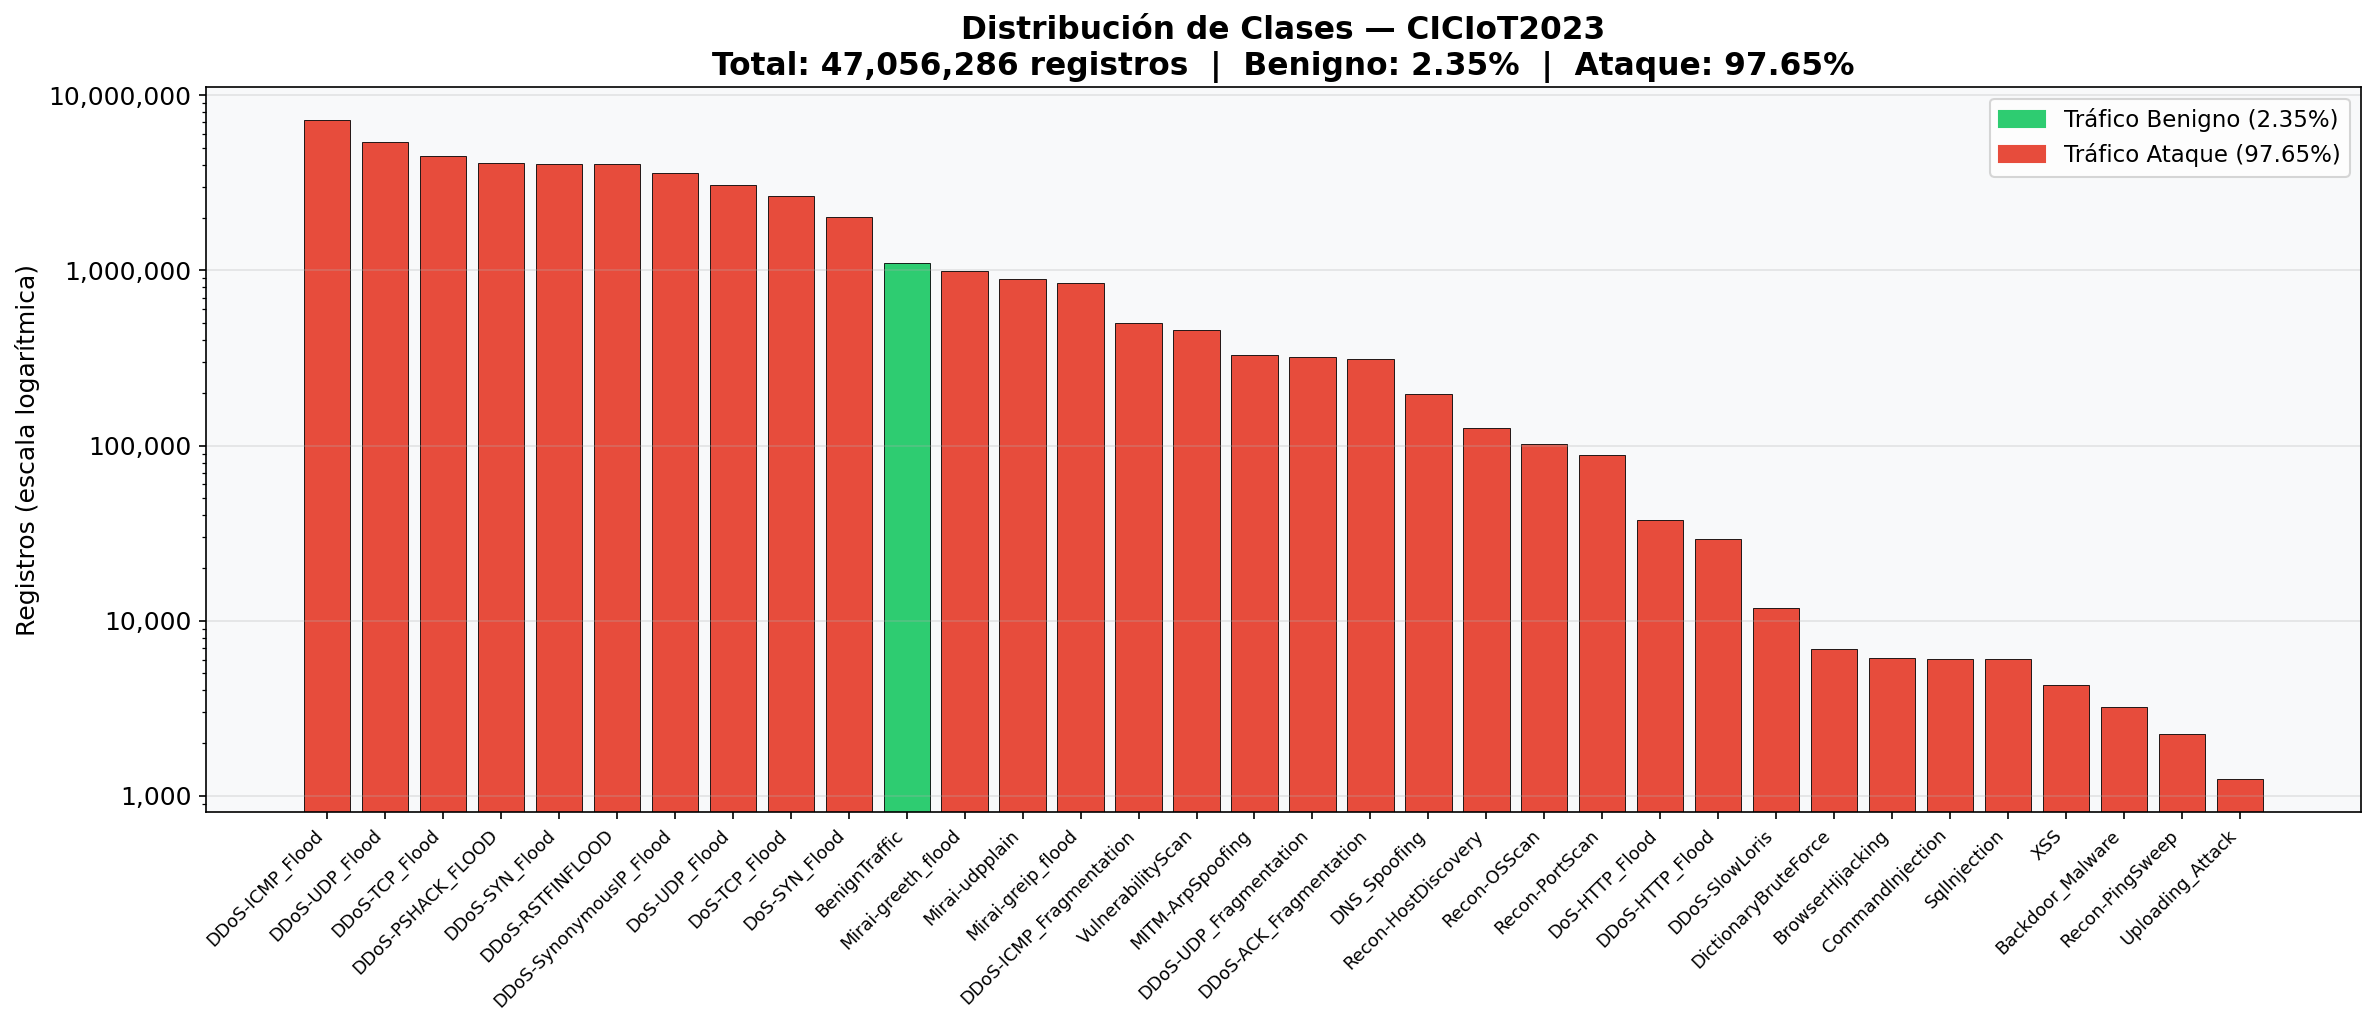

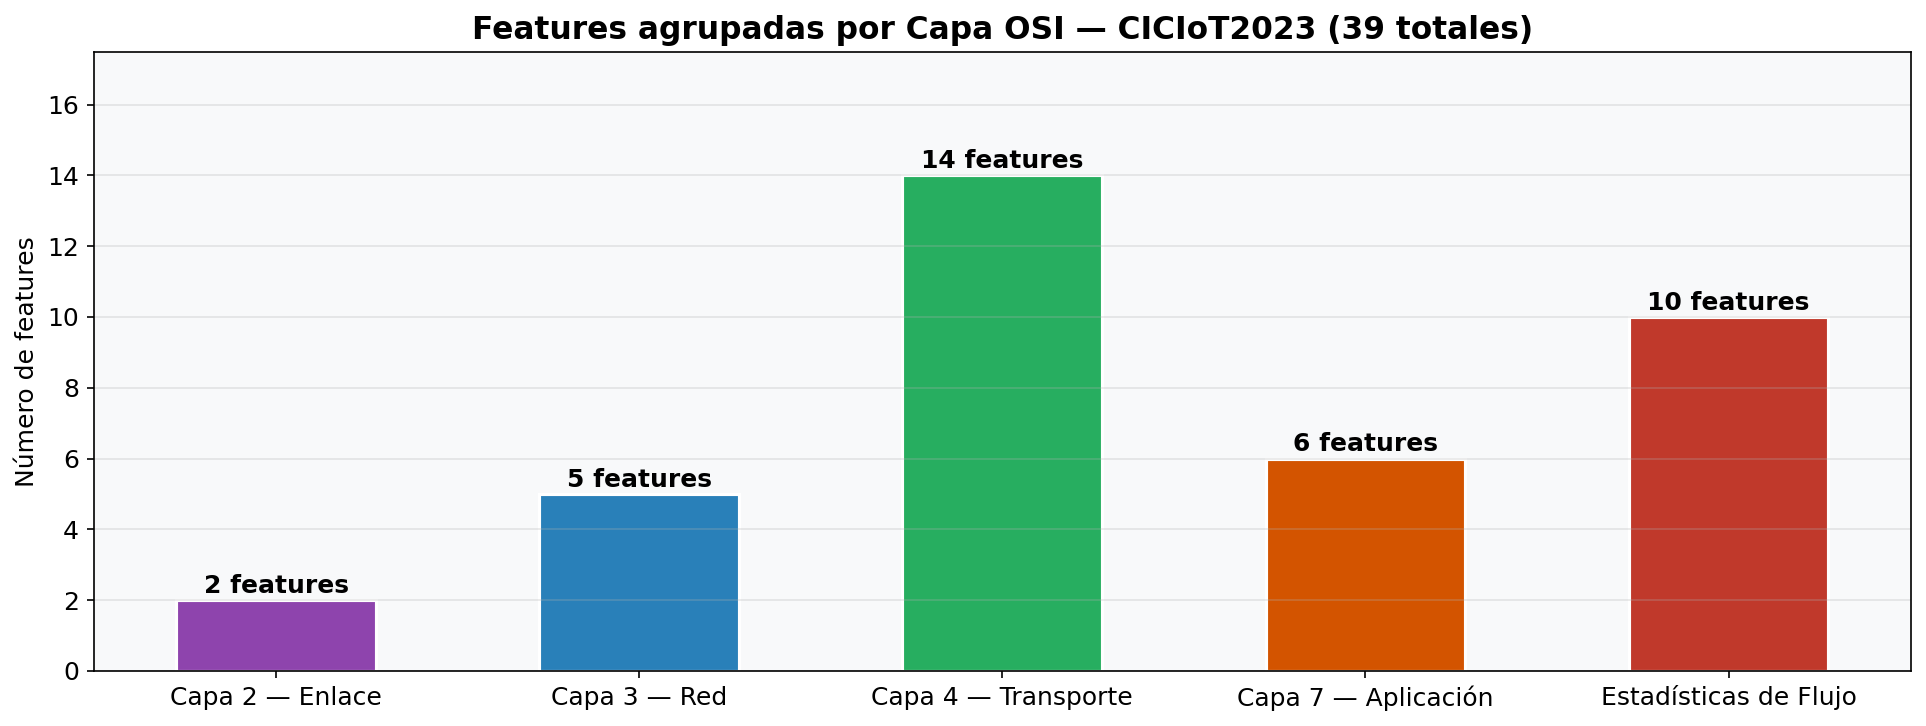


  Gráficas guardadas en: C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\fase3_salidas\graficas_pipeline


In [8]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 2 — CATÁLOGO Y GRÁFICAS DEL DATASET
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 15,
                     'figure.dpi': 150, 'axes.labelsize': 12})

# ── Construir catálogo ────────────────────────────────────────────
catalogo = {}
for carpeta in sorted(CSV_ROOT.iterdir()):
    if not carpeta.is_dir():
        continue
    archivos = sorted(carpeta.glob('*.csv'))
    if not archivos:
        continue
    size_mb = sum(f.stat().st_size for f in archivos) / (1024**2)
    catalogo[carpeta.name] = {
        'archivos':   archivos,
        'n_archivos': len(archivos),
        'size_mb':    round(size_mb, 2),
        'tipo':       'benigno' if 'Benign' in carpeta.name else 'ataque',
    }

CLASE_BENIGNA = 'Benign_Final'
CLASES_ATAQUE = sorted([k for k in catalogo if k != CLASE_BENIGNA])

df_cat = pd.DataFrame([
    {'clase': k, 'tipo': v['tipo'],
     'n_archivos': v['n_archivos'], 'size_mb': v['size_mb']}
    for k, v in catalogo.items()
]).sort_values('size_mb', ascending=False).reset_index(drop=True)

print(df_cat.to_string(index=False))

# ── Gráfica 1: Distribución de clases (escala log) ────────────────
# Hardcoded desde conteos reales del dataset
CONTEOS_REALES = {
    'BenignTraffic': 1098126, 'DDoS-ICMP_Flood': 7200501,
    'DDoS-UDP_Flood': 5412231, 'DDoS-TCP_Flood': 4497649,
    'DDoS-PSHACK_FLOOD': 4094772, 'DDoS-SYN_Flood': 4059179,
    'DDoS-RSTFINFLOOD': 4045279, 'DDoS-SynonymousIP_Flood': 3598133,
    'DoS-UDP_Flood': 3072993, 'DoS-TCP_Flood': 2671430,
    'DoS-SYN_Flood': 2028836, 'Mirai-greeth_flood': 991834,
    'Mirai-udpplain': 890574, 'Mirai-greip_flood': 849543,
    'DDoS-ICMP_Fragmentation': 502012, 'VulnerabilityScan': 455635,
    'MITM-ArpSpoofing': 326813, 'DDoS-UDP_Fragmentation': 318434,
    'DDoS-ACK_Fragmentation': 312789, 'DNS_Spoofing': 197748,
    'Recon-HostDiscovery': 126721, 'Recon-OSScan': 102476,
    'Recon-PortScan': 87903, 'DoS-HTTP_Flood': 37637,
    'DDoS-HTTP_Flood': 29143, 'DDoS-SlowLoris': 11812,
    'DictionaryBruteForce': 6893, 'BrowserHijacking': 6106,
    'CommandInjection': 6043, 'SqlInjection': 6023,
    'XSS': 4286, 'Backdoor_Malware': 3218,
    'Recon-PingSweep': 2262, 'Uploading_Attack': 1252,
}

series  = pd.Series(CONTEOS_REALES).sort_values(ascending=False)
total   = series.sum()
colores = ['#2ecc71' if k == 'BenignTraffic' else '#e74c3c' for k in series.index]

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_facecolor(PALETA['fondo'])
ax.bar(range(len(series)), series.values, color=colores,
       edgecolor='black', linewidth=0.4)
ax.set_yscale('log')
ax.set_xticks(range(len(series)))
ax.set_xticklabels(series.index, rotation=45, ha='right', fontsize=8.5)
ax.set_title(
    f'Distribución de Clases — CICIoT2023\n'
    f'Total: {total:,} registros  |  Benigno: 2.35%  |  Ataque: 97.65%',
    fontweight='bold')
ax.set_ylabel('Registros (escala logarítmica)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
leyenda = [
    mpatches.Patch(color='#2ecc71', label='Tráfico Benigno (2.35%)'),
    mpatches.Patch(color='#e74c3c', label='Tráfico Ataque (97.65%)'),
]
ax.legend(handles=leyenda, fontsize=11)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfica 2: Features por capa OSI ─────────────────────────────
COLORES_GRUPO = {
    'Capa 2 — Enlace': '#8e44ad', 'Capa 3 — Red': '#2980b9',
    'Capa 4 — Transporte': '#27ae60', 'Capa 7 — Aplicación': '#d35400',
    'Estadísticas de Flujo': '#c0392b',
}
grupos  = list(GRUPOS_OSI.keys())
conteos_g = [len(v) for v in GRUPOS_OSI.values()]
colores_g = [COLORES_GRUPO[g] for g in grupos]

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_facecolor(PALETA['fondo'])
bars = ax.bar(grupos, conteos_g, color=colores_g,
              edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, conteos_g):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val} features', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de features')
ax.set_title('Features agrupadas por Capa OSI — CICIoT2023 (39 totales)',
             fontweight='bold')
ax.set_ylim(0, max(conteos_g) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'features_por_osi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n  Gráficas guardadas en: {GRAF_DIR}')

---
## SECCIÓN 3 — Carga y Limpieza del Tráfico Benigno

In [9]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 3 — CARGA Y LIMPIEZA DEL BENIGNO
#  Lee todos los CSVs de Benign_Final, limpia NaN/inf/duplicados
#  Produce: particiones/benign_full.csv
# ════════════════════════════════════════════════════════════════

import gc
from sklearn.model_selection import train_test_split

print('=' * 65)
print('  PASO 1 — Cargando tráfico benigno')
print('=' * 65)

carpeta_benigna = CSV_ROOT / 'Benign_Final'
archivos_benignos = sorted(carpeta_benigna.glob('*.csv'))
chunks = []

for i, archivo in enumerate(archivos_benignos, 1):
    print(f'  [{i}/{len(archivos_benignos)}] {archivo.name} ...', end=' ')
    df_chunk = pd.read_csv(archivo, usecols=lambda c: c in FEATURES_39,
                           low_memory=False)
    cols = [f for f in FEATURES_39 if f in df_chunk.columns]
    df_chunk = df_chunk[cols]
    print(f'{len(df_chunk):,} filas')
    chunks.append(df_chunk)

df_benign = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'\n  Total cargado: {len(df_benign):,} filas × {df_benign.shape[1]} features')

# ── Limpieza ──────────────────────────────────────────────────────
print()
print('=' * 65)
print('  PASO 2 — Limpieza')
print('=' * 65)
n0 = len(df_benign)

# Reemplazar inf por NaN columna por columna (evita convertir todo a numpy)
cols_float = df_benign.select_dtypes(include=[float]).columns
for col in cols_float:
    df_benign[col] = df_benign[col].replace([np.inf, -np.inf], np.nan)

df_benign.dropna(inplace=True)
n1 = len(df_benign)
print(f'  Filas eliminadas por NaN/Inf:  {n0 - n1:,}')

# Eliminar duplicados
df_benign.drop_duplicates(subset=FEATURES_39, inplace=True)
n2 = len(df_benign)
print(f'  Filas duplicadas eliminadas:   {n1 - n2:,}')
print(f'  Benigno limpio final:          {n2:,} filas')

# Guardar benign_full.csv
PATH_BENIGN_FULL = PART_DIR / 'benign_full.csv'
df_benign.to_csv(PATH_BENIGN_FULL, index=False)
size_mb = PATH_BENIGN_FULL.stat().st_size / (1024**2)
print(f'\n  ✓ benign_full.csv guardado → {n2:,} filas  ({size_mb:.1f} MB)')

# ── División 80/20 ANTES de normalizar (evita data leakage) ───────
print()
print('=' * 65)
print('  PASO 3 — División 80/20')
print('  (ANTES de normalizar para evitar data leakage)')
print('=' * 65)

df_train, df_val = train_test_split(
    df_benign,
    test_size=VAL_SIZE,
    random_state=SEED,
    shuffle=True
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
del df_benign; gc.collect()

PATH_TRAIN = PART_DIR / 'benign_train_80.csv'
PATH_VAL   = PART_DIR / 'benign_val_20.csv'
df_train.to_csv(PATH_TRAIN, index=False)
df_val.to_csv(PATH_VAL,   index=False)

print(f'  ✓ benign_train_80.csv  →  {len(df_train):,} filas  (80%)')
print(f'  ✓ benign_val_20.csv    →  {len(df_val):,} filas  (20%)')

  PASO 1 — Cargando tráfico benigno
  [1/4] BenignTraffic.pcap.csv ... 362,361 filas
  [2/4] BenignTraffic1.pcap.csv ... 295,585 filas
  [3/4] BenignTraffic2.pcap.csv ... 310,413 filas
  [4/4] BenignTraffic3.pcap.csv ... 129,832 filas

  Total cargado: 1,098,191 filas × 39 features

  PASO 2 — Limpieza
  Filas eliminadas por NaN/Inf:  65
  Filas duplicadas eliminadas:   4,250
  Benigno limpio final:          1,093,876 filas

  ✓ benign_full.csv guardado → 1,093,876 filas  (217.1 MB)

  PASO 3 — División 80/20
  (ANTES de normalizar para evitar data leakage)
  ✓ benign_train_80.csv  →  875,100 filas  (80%)
  ✓ benign_val_20.csv    →  218,776 filas  (20%)


---
## SECCIÓN 4 — Análisis de Features Constantes (Telnet y SMTP)
**Justificación de la eliminación de Telnet y SMTP.**

In [10]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 4 — ANÁLISIS DE FEATURES CONSTANTES
#  Demuestra por qué Telnet y SMTP deben eliminarse
# ════════════════════════════════════════════════════════════════

print('=' * 65)
print('  ANÁLISIS — Telnet y SMTP en tráfico benigno')
print('=' * 65)

df_full = pd.read_csv(PATH_BENIGN_FULL, usecols=['Telnet', 'SMTP'])
total = len(df_full)

for feat in ['Telnet', 'SMTP']:
    col    = df_full[feat]
    ceros  = (col == 0).sum()
    nceros = (col != 0).sum()
    media  = col.mean()
    std    = col.std()
    iqr    = col.quantile(0.75) - col.quantile(0.25)
    print(f'\n  Feature: {feat}')
    print(f'    Valores = 0:      {ceros:,}  ({ceros/total*100:.4f}%)')
    print(f'    Valores ≠ 0:      {nceros:,}  ({nceros/total*100:.4f}%)')
    print(f'    Media:            {media:.8f}')
    print(f'    Std:              {std:.8f}')
    print(f'    IQR (Q3-Q1):      {iqr:.8f}')
    if iqr == 0:
        print(f'    → IQR=0 → RobustScaler dividiría entre CERO → ELIMINADA ✓')

del df_full; gc.collect()

# ── Verificar también en ataques ──────────────────────────────────
print()
print('=' * 65)
print('  VERIFICACIÓN en datos de ATAQUE (¿existen valores ≠ 0?)')
print('=' * 65)

total_telnet = 0
total_smtp   = 0
total_filas  = 0

for carpeta in sorted(CSV_ROOT.iterdir()):
    if not carpeta.is_dir() or 'Benign' in carpeta.name:
        continue
    for archivo in sorted(carpeta.glob('*.csv')):
        df_tmp = pd.read_csv(archivo, usecols=['Telnet', 'SMTP'],
                             low_memory=False)
        total_telnet += (df_tmp['Telnet'] != 0).sum()
        total_smtp   += (df_tmp['SMTP'] != 0).sum()
        total_filas  += len(df_tmp)
        del df_tmp
    gc.collect()

print(f'  Total filas de ataque analizadas: {total_filas:,}')
print(f'  Telnet ≠ 0 en ataques: {total_telnet:,}  ({total_telnet/total_filas*100:.4f}%)')
print(f'  SMTP   ≠ 0 en ataques: {total_smtp:,}  ({total_smtp/total_filas*100:.4f}%)')
print()
print('  DECISIÓN FINAL:')
print(f'  → Se eliminan Telnet y SMTP de las 39 features')
print(f'  → Features finales: 37')
print(f'  → Justificación técnica: IQR=0 en benigno → división por cero en RobustScaler')
print(f'  → En ataques: <0.084% de valores no-cero → documentado como limitación conocida')

  ANÁLISIS — Telnet y SMTP en tráfico benigno

  Feature: Telnet
    Valores = 0:      1,093,876  (100.0000%)
    Valores ≠ 0:      0  (0.0000%)
    Media:            0.00000000
    Std:              0.00000000
    IQR (Q3-Q1):      0.00000000
    → IQR=0 → RobustScaler dividiría entre CERO → ELIMINADA ✓

  Feature: SMTP
    Valores = 0:      1,093,876  (100.0000%)
    Valores ≠ 0:      0  (0.0000%)
    Media:            0.00000000
    Std:              0.00000000
    IQR (Q3-Q1):      0.00000000
    → IQR=0 → RobustScaler dividiría entre CERO → ELIMINADA ✓

  VERIFICACIÓN en datos de ATAQUE (¿existen valores ≠ 0?)
  Total filas de ataque analizadas: 45,678,509
  Telnet ≠ 0 en ataques: 38,382  (0.0840%)
  SMTP   ≠ 0 en ataques: 38,275  (0.0838%)

  DECISIÓN FINAL:
  → Se eliminan Telnet y SMTP de las 39 features
  → Features finales: 37
  → Justificación técnica: IQR=0 en benigno → división por cero en RobustScaler
  → En ataques: <0.084% de valores no-cero → documentado como limitació

---
## SECCIÓN 5 — Construcción del Conjunto de Test de Ataques
Muestreo estratificado: mínimo garantizado por clase + distribución proporcional.

In [11]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 5 — CONSTRUCCIÓN DEL TEST DE ATAQUES
#  Muestreo estratificado con mínimo garantizado por clase
#  Produce: particiones/attack_test.csv
# ════════════════════════════════════════════════════════════════

# ── Mapear clases de ataque ───────────────────────────────────────
catalogo_ataque = {}
for carpeta in sorted(CSV_ROOT.iterdir()):
    if carpeta.is_dir() and 'Benign' not in carpeta.name:
        archivos = sorted(carpeta.glob('*.csv'))
        if archivos:
            catalogo_ataque[carpeta.name] = archivos

CLASES_ATAQUE = sorted(catalogo_ataque.keys())
print(f'  Clases de ataque mapeadas: {len(CLASES_ATAQUE)}')

# ── Contar filas disponibles por clase ───────────────────────────
print()
print('  Contando filas disponibles...')
conteo_clases = {}
for clase in CLASES_ATAQUE:
    total = 0
    for arch in catalogo_ataque[clase]:
        df_tmp = pd.read_csv(arch, usecols=[FEATURES_39[0]])
        total += len(df_tmp)
    conteo_clases[clase] = total

total_disponible = sum(conteo_clases.values())

# ── Calcular asignación estratificada ────────────────────────────
# Objetivo: ~igual al conjunto de validación benigno
df_val_temp = pd.read_csv(PATH_VAL, usecols=[FEATURES_37[0]])
N_OBJETIVO  = len(df_val_temp)
del df_val_temp

asignacion = {clase: N_MIN_CLASE for clase in CLASES_ATAQUE}
presupuesto = N_OBJETIVO - N_MIN_CLASE * len(CLASES_ATAQUE)
total_grandes = sum(max(0, v - N_MIN_CLASE) for v in conteo_clases.values())

if presupuesto > 0 and total_grandes > 0:
    for clase, disp in conteo_clases.items():
        excedente = max(0, disp - N_MIN_CLASE)
        extra = int(presupuesto * (excedente / total_grandes))
        asignacion[clase] = min(N_MIN_CLASE + extra, disp)

print(f'\n  {"Clase":<45} {"Disponible":>12} {"Asignado":>10}')
print(f'  {"-"*70}')
for clase in CLASES_ATAQUE:
    print(f'  {clase:<45} {conteo_clases[clase]:>12,} {asignacion[clase]:>10,}')
print(f'  {"-"*70}')
print(f'  {"TOTAL":<45} {total_disponible:>12,} {sum(asignacion.values()):>10,}')

# ── Muestrear cada clase ──────────────────────────────────────────
print()
print('=' * 65)
print('  Muestreando clases de ataque...')
print('=' * 65)

partes = []
np.random.seed(SEED)

for i, clase in enumerate(CLASES_ATAQUE, 1):
    chunks_clase = []
    for arch in catalogo_ataque[clase]:
        df_tmp = pd.read_csv(arch, usecols=lambda c: c in FEATURES_39,
                             low_memory=False)
        cols = [f for f in FEATURES_39 if f in df_tmp.columns]
        df_tmp = df_tmp[cols]
        df_tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_tmp.dropna(inplace=True)
        chunks_clase.append(df_tmp)
        del df_tmp

    df_clase  = pd.concat(chunks_clase, ignore_index=True)
    del chunks_clase
    n_tomar   = min(asignacion[clase], len(df_clase))
    df_muestra = df_clase.sample(n=n_tomar, random_state=SEED).copy()
    df_muestra['clase_ataque'] = clase
    partes.append(df_muestra)
    print(f'  [{i:02d}/{len(CLASES_ATAQUE)}] {clase:<45} {n_tomar:,} ✓')
    del df_clase, df_muestra
    gc.collect()

df_attack = pd.concat(partes, ignore_index=True)
df_attack = df_attack.sample(frac=1, random_state=SEED).reset_index(drop=True)
PATH_ATK  = PART_DIR / 'attack_test.csv'
df_attack.to_csv(PATH_ATK, index=False)
print(f'\n  ✓ attack_test.csv → {len(df_attack):,} filas  ({df_attack["clase_ataque"].nunique()} tipos)')
del df_attack, partes
gc.collect()

  Clases de ataque mapeadas: 33

  Contando filas disponibles...

  Clase                                           Disponible   Asignado
  ----------------------------------------------------------------------
  Backdoor_Malware                                     3,218        512
  BrowserHijacking                                     5,859        523
  CommandInjection                                     5,409        521
  DDoS-ACK_Fragmentation                             285,075      1,760
  DDoS-HTTP_Flood                                     28,790        625
  DDoS-ICMP_Flood                                  7,200,501     32,394
  DDoS-ICMP_Fragmentation                            452,490      2,502
  DDoS-PSHACK_FLOOD                                4,094,772     18,637
  DDoS-RSTFINFLOOD                                 4,045,279     18,417
  DDoS-SYN_Flood                                   4,059,179     18,479
  DDoS-SlowLoris                                      23,426        6

0

---
## SECCIÓN 6 — Normalización con RobustScaler
**Fit solo en train benigno. Transform sin reajuste en val y ataques.**

In [12]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 6 — NORMALIZACIÓN CON ROBUSTSCALER
#  Fórmula: X' = (X - Q2) / IQR
#  Q2 = mediana, IQR = Q3 - Q1
#  El scaler aprende SOLO del train benigno (evita data leakage)
# ════════════════════════════════════════════════════════════════

import pickle
from sklearn.preprocessing import RobustScaler

print('=' * 65)
print('  PASO 1 — Fit del RobustScaler sobre train benigno')
print('  (aprende Q2 e IQR de cada una de las 37 features)')
print('=' * 65)

# Cargar train con solo las 37 features finales
print(f'  Cargando benign_train_80.csv ...', end=' ')
df_train = pd.read_csv(PATH_TRAIN, usecols=FEATURES_37)[FEATURES_37]
print(f'{len(df_train):,} filas × {df_train.shape[1]} features')

# Fit SOLO en train
scaler = RobustScaler()
scaler.fit(df_train)

PATH_SCALER = NORM_DIR / 'scaler.pkl'
with open(PATH_SCALER, 'wb') as f:
    pickle.dump(scaler, f)
print(f'  ✓ scaler.pkl guardado')
print(f'  Mediana Q2  (primeras 5): {scaler.center_[:5].round(4)}')
print(f'  IQR (Q3-Q1) (primeras 5): {scaler.scale_[:5].round(4)}')

# ── Transform train ───────────────────────────────────────────────
print()
print('  PASO 2 — Transform train')
train_norm = scaler.transform(df_train).astype(np.float32)
np.save(NORM_DIR / 'train_norm.npy', train_norm)
print(f'  train_norm.npy  shape={train_norm.shape}  '
      f'min={train_norm.min():.3f}  max={train_norm.max():.3f}  '
      f'mean={train_norm.mean():.4f}')
del df_train, train_norm; gc.collect()

# ── Transform val ─────────────────────────────────────────────────
print()
print('  PASO 3 — Transform val benigno (sin reajuste del scaler)')
df_val = pd.read_csv(PATH_VAL, usecols=FEATURES_37)[FEATURES_37]
val_norm = scaler.transform(df_val).astype(np.float32)
np.save(NORM_DIR / 'val_norm.npy', val_norm)
print(f'  val_norm.npy    shape={val_norm.shape}  mean={val_norm.mean():.4f}')
del df_val, val_norm; gc.collect()

# ── Transform ataques ─────────────────────────────────────────────
print()
print('  PASO 4 — Transform attack test (sin reajuste del scaler)')
df_atk = pd.read_csv(PATH_ATK)
labels = df_atk['clase_ataque'].values
np.save(NORM_DIR / 'atk_labels.npy', labels)
print(f'  atk_labels.npy  {len(labels):,} etiquetas  ({len(np.unique(labels))} clases)')

atk_norm = scaler.transform(df_atk[FEATURES_37]).astype(np.float32)
np.save(NORM_DIR / 'atk_norm.npy', atk_norm)
print(f'  atk_norm.npy    shape={atk_norm.shape}  mean={atk_norm.mean():.4f}')
del df_atk, atk_norm, labels; gc.collect()

# ── Resumen ───────────────────────────────────────────────────────
print()
print('=' * 65)
print('  RESUMEN — normalizacion/')
print('=' * 65)
for p in sorted(NORM_DIR.glob('*')):
    size = p.stat().st_size / (1024**2)
    print(f'  {p.name:25}  {size:.1f} MB')

  PASO 1 — Fit del RobustScaler sobre train benigno
  (aprende Q2 e IQR de cada una de las 37 features)
  Cargando benign_train_80.csv ... 875,100 filas × 37 features
  ✓ scaler.pkl guardado
  Mediana Q2  (primeras 5): [ 29.6      6.      98.8    170.7768   0.    ]
  IQR (Q3-Q1) (primeras 5): [  8.       1.      73.6    506.2193   1.    ]

  PASO 2 — Transform train
  train_norm.npy  shape=(875100, 37)  min=-8.000  max=6213.823  mean=0.4753

  PASO 3 — Transform val benigno (sin reajuste del scaler)
  val_norm.npy    shape=(218776, 37)  mean=0.4722

  PASO 4 — Transform attack test (sin reajuste del scaler)
  atk_labels.npy  218,760 etiquetas  (33 clases)
  atk_norm.npy    shape=(218760, 37)  mean=4.7846

  RESUMEN — normalizacion/
  atk_labels.npy             0.7 MB
  atk_norm.npy               30.9 MB
  scaler.pkl                 0.0 MB
  train_norm.npy             123.5 MB
  val_norm.npy               30.9 MB


---
## SECCIÓN 7 — Análisis Exploratorio de Datos (EDA)
Histogramas, boxplots, heatmap de correlación y comparación benigno vs ataque.

  Cargando muestras para EDA...
  Benigno: 50,000 muestras  |  Ataque: 50,000 muestras


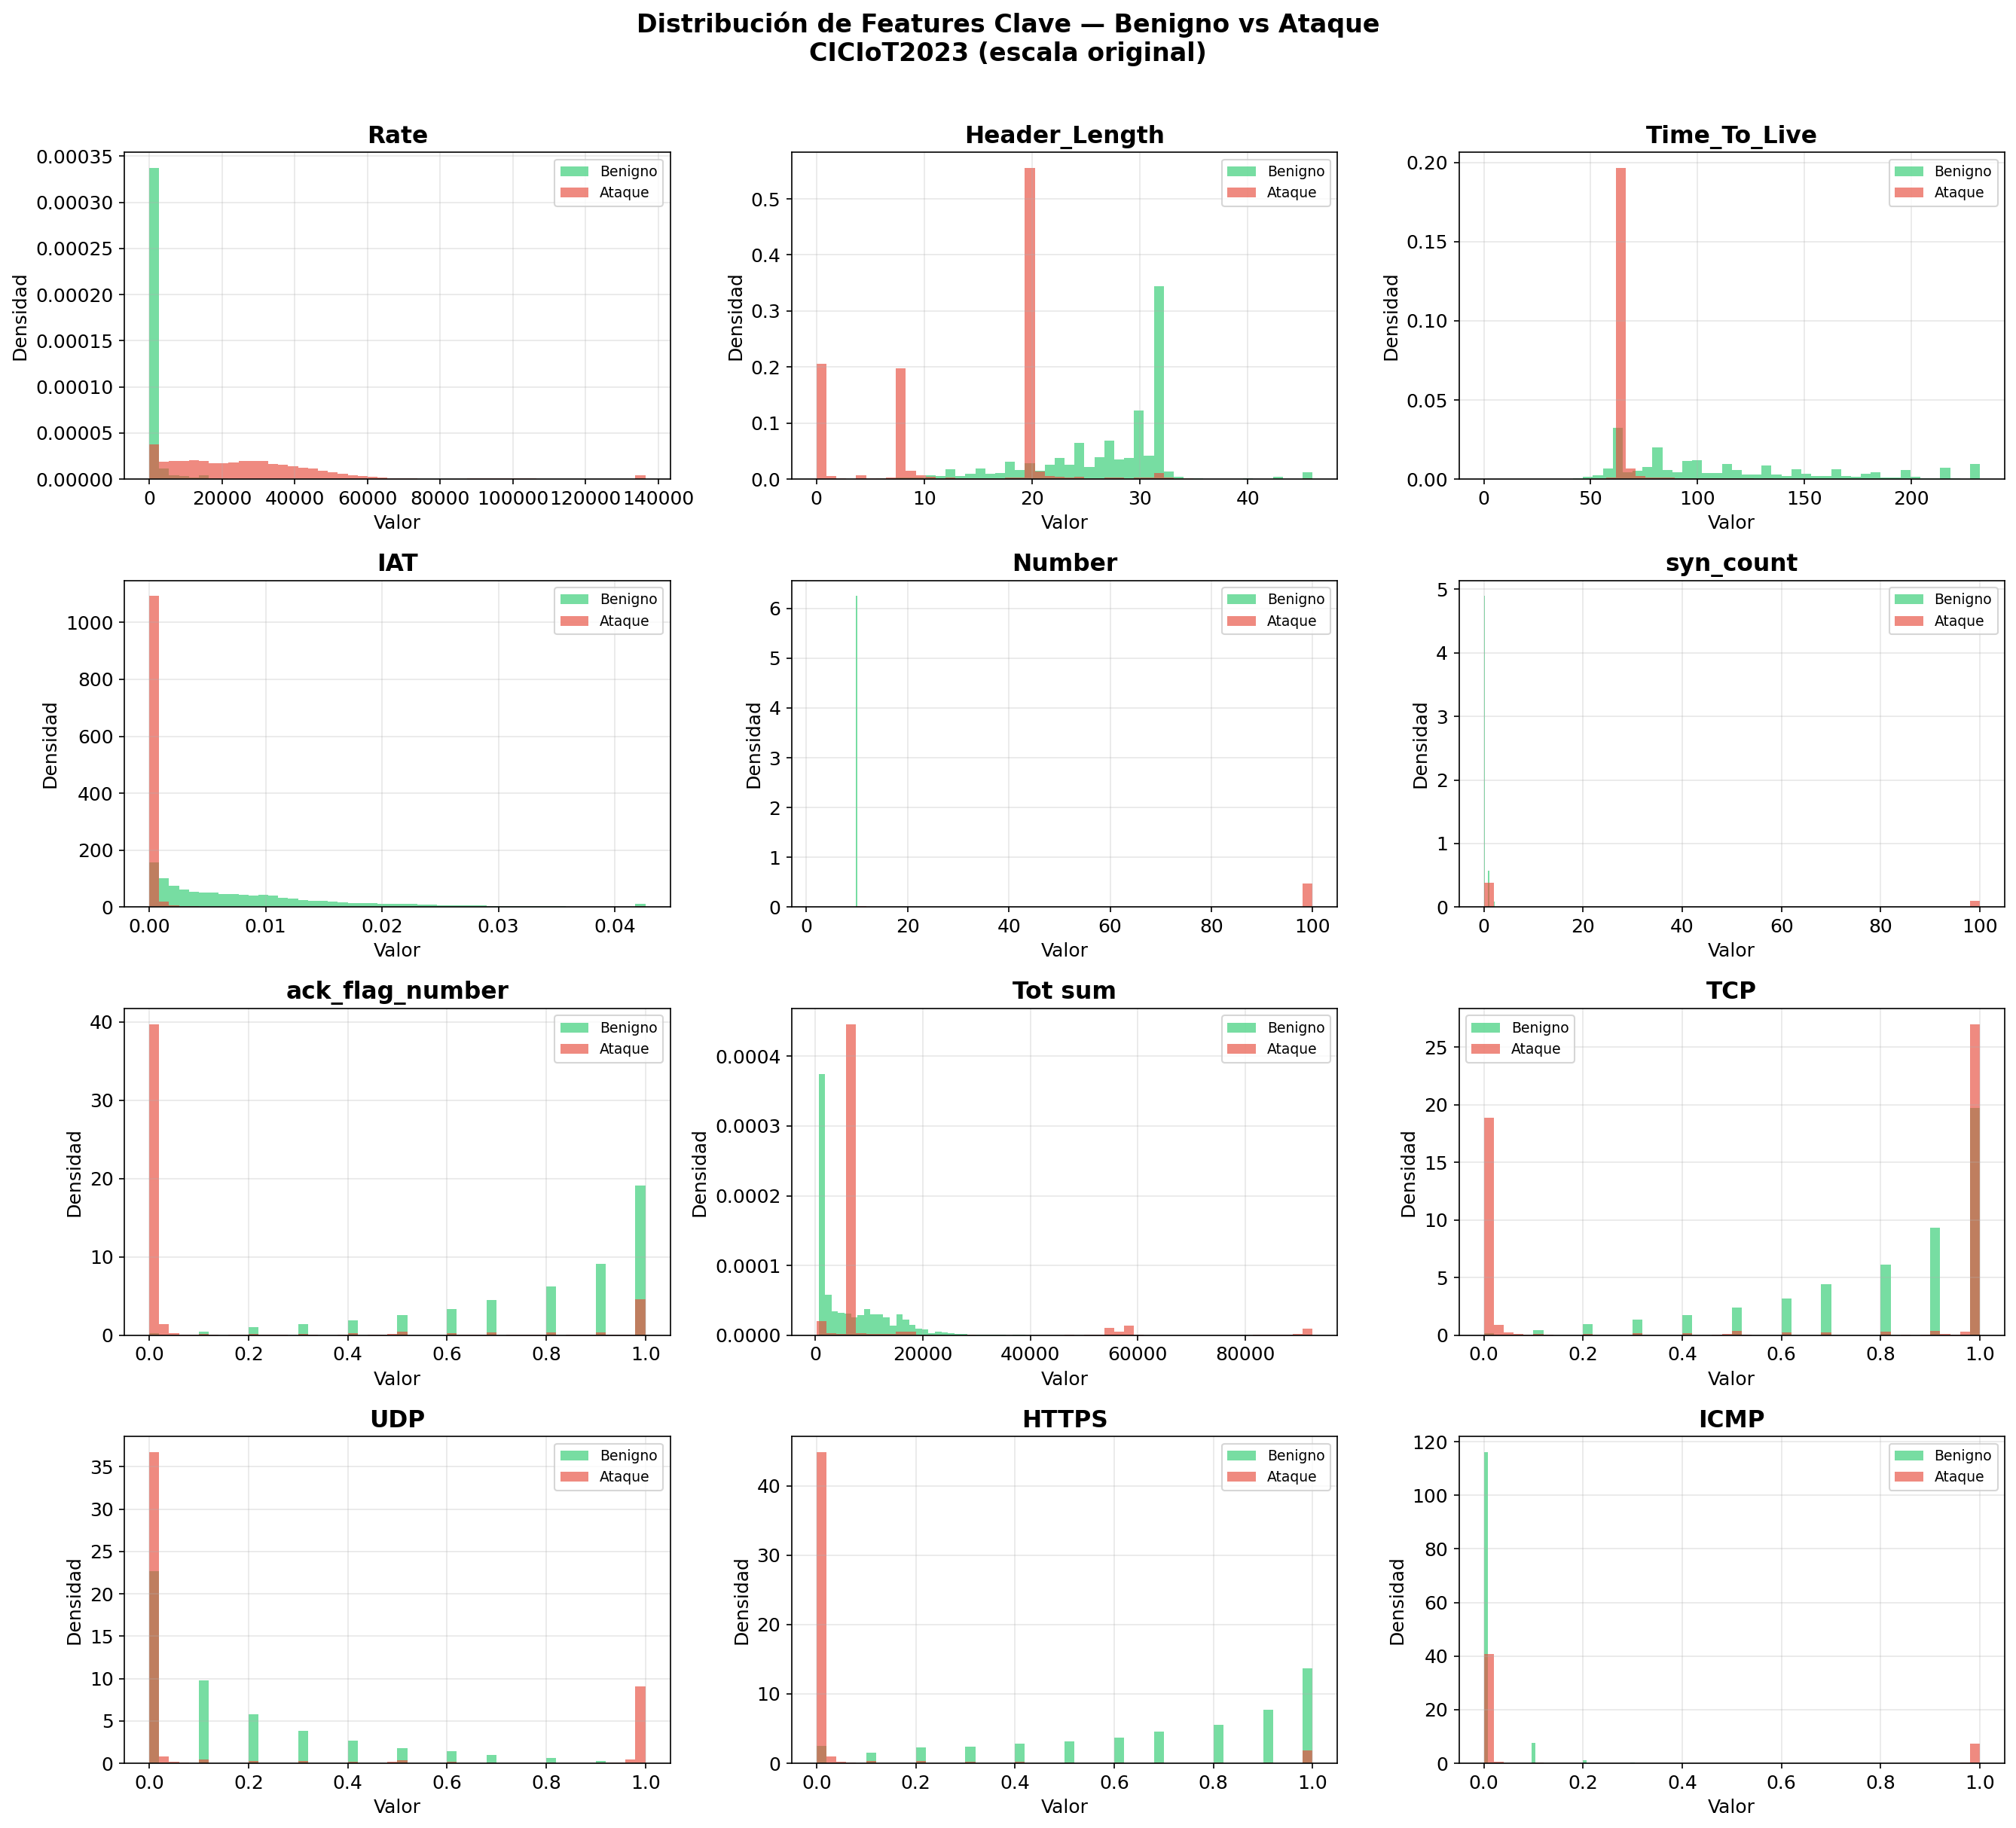

  ✓ eda_histogramas.png


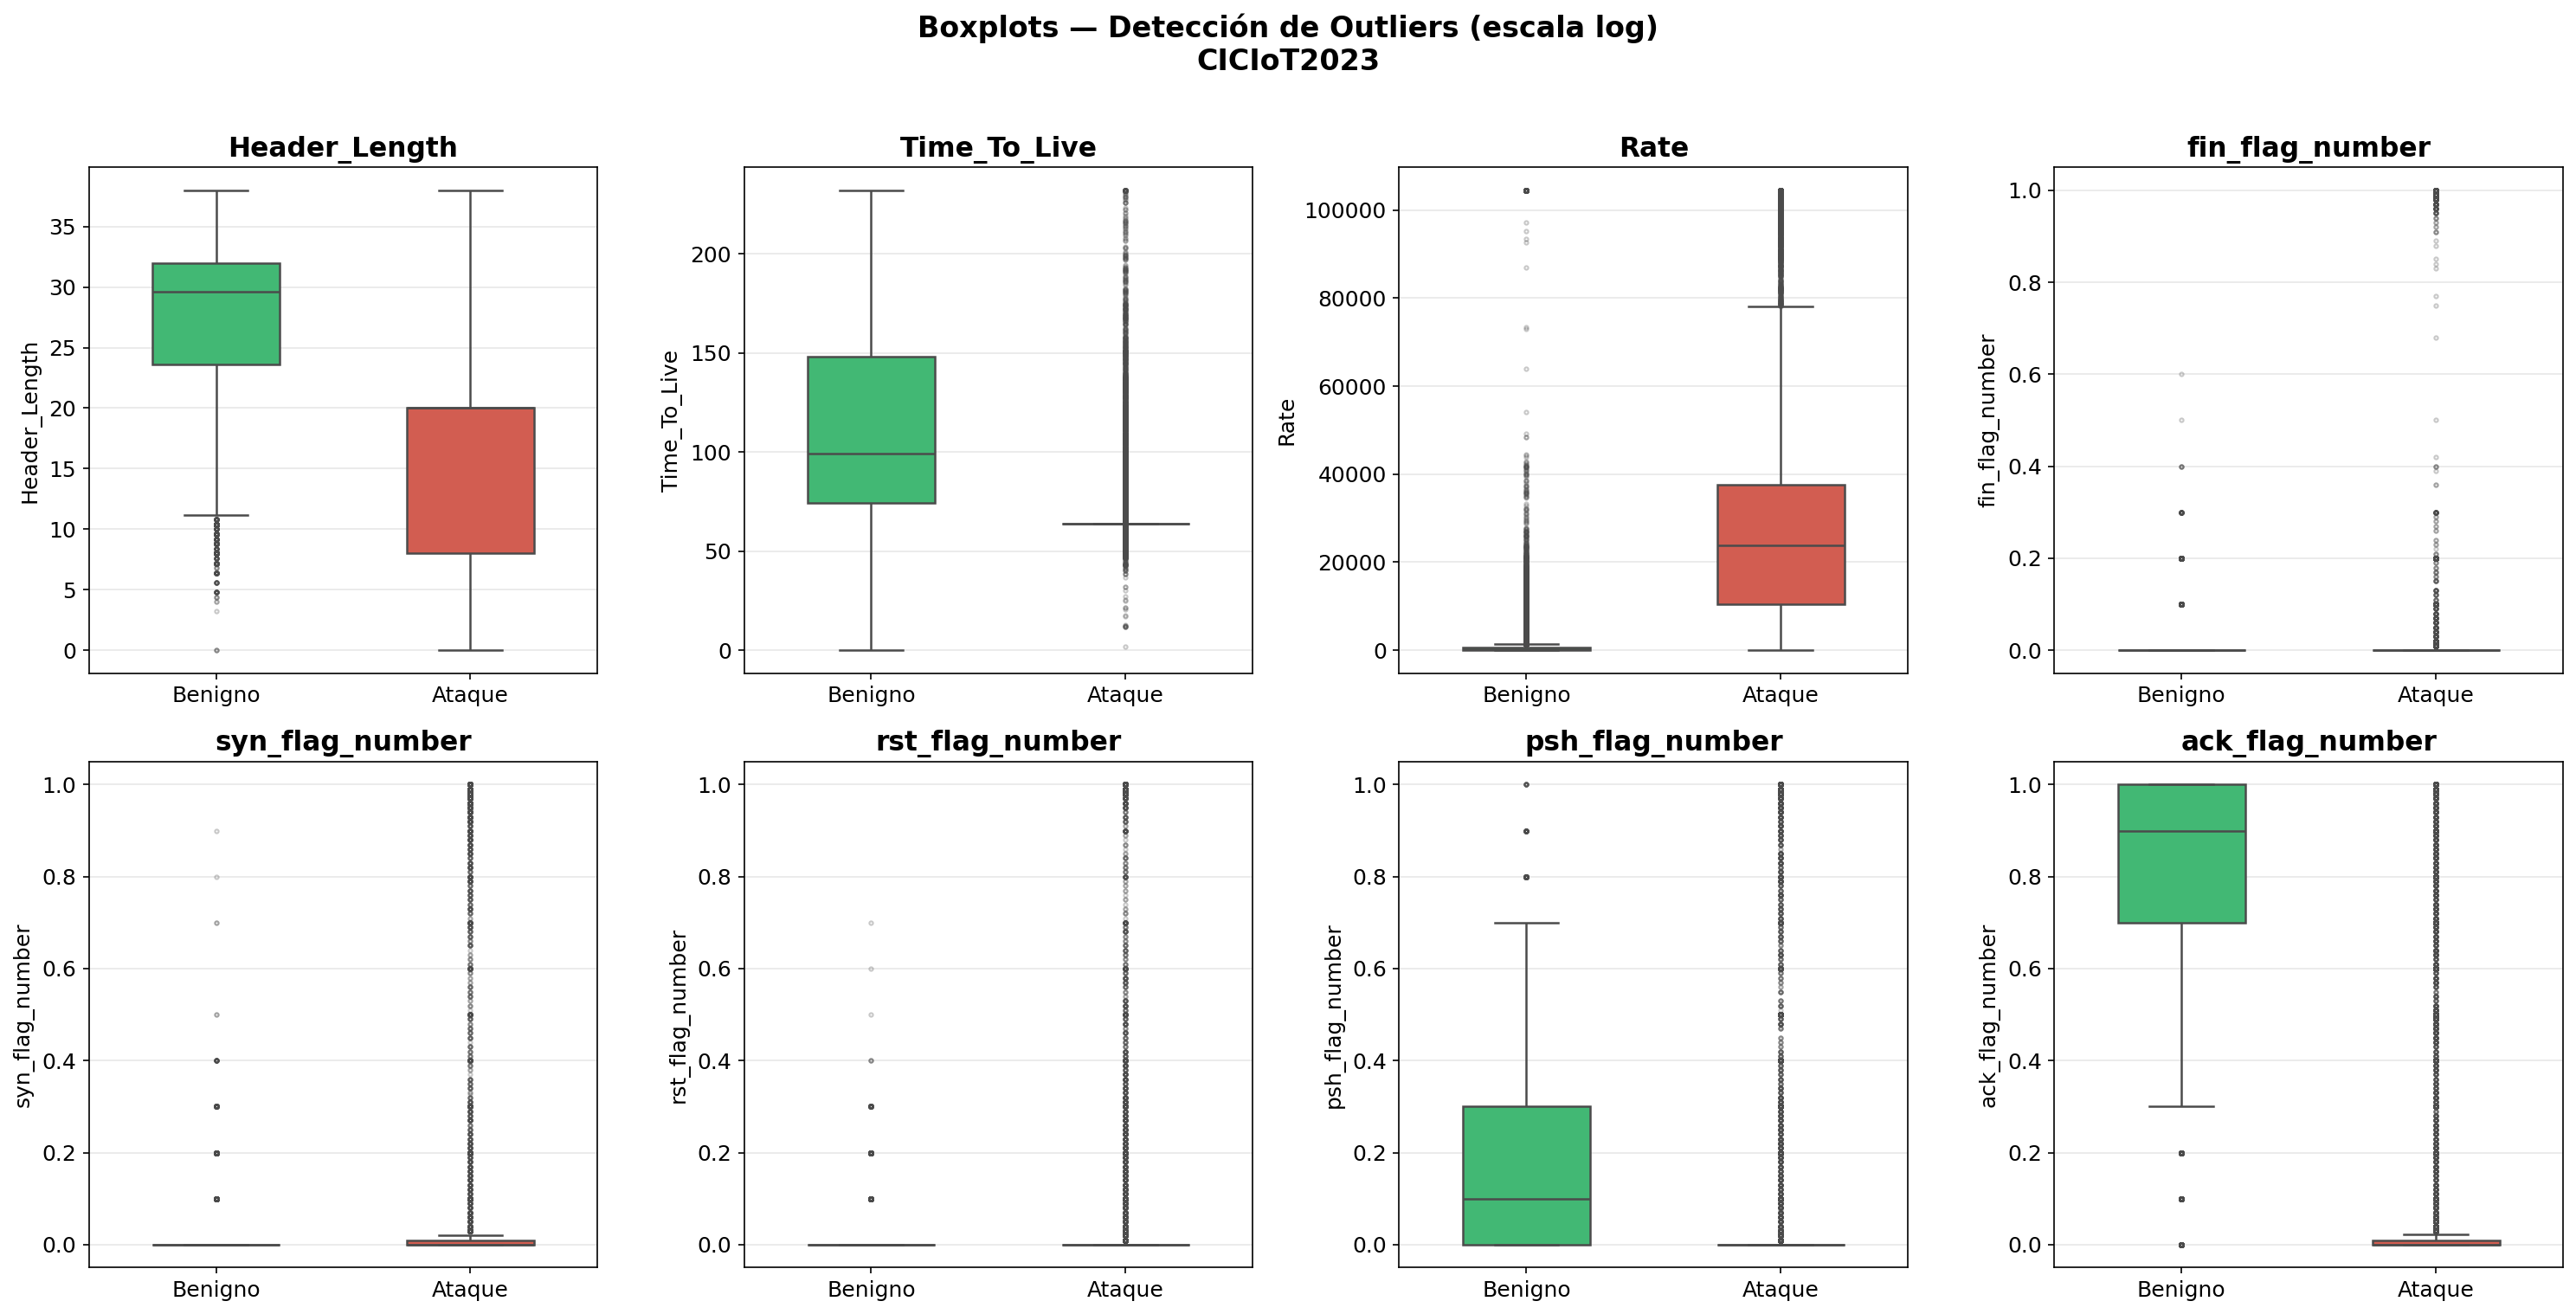

  ✓ eda_boxplots.png
  Generando heatmap de correlación...


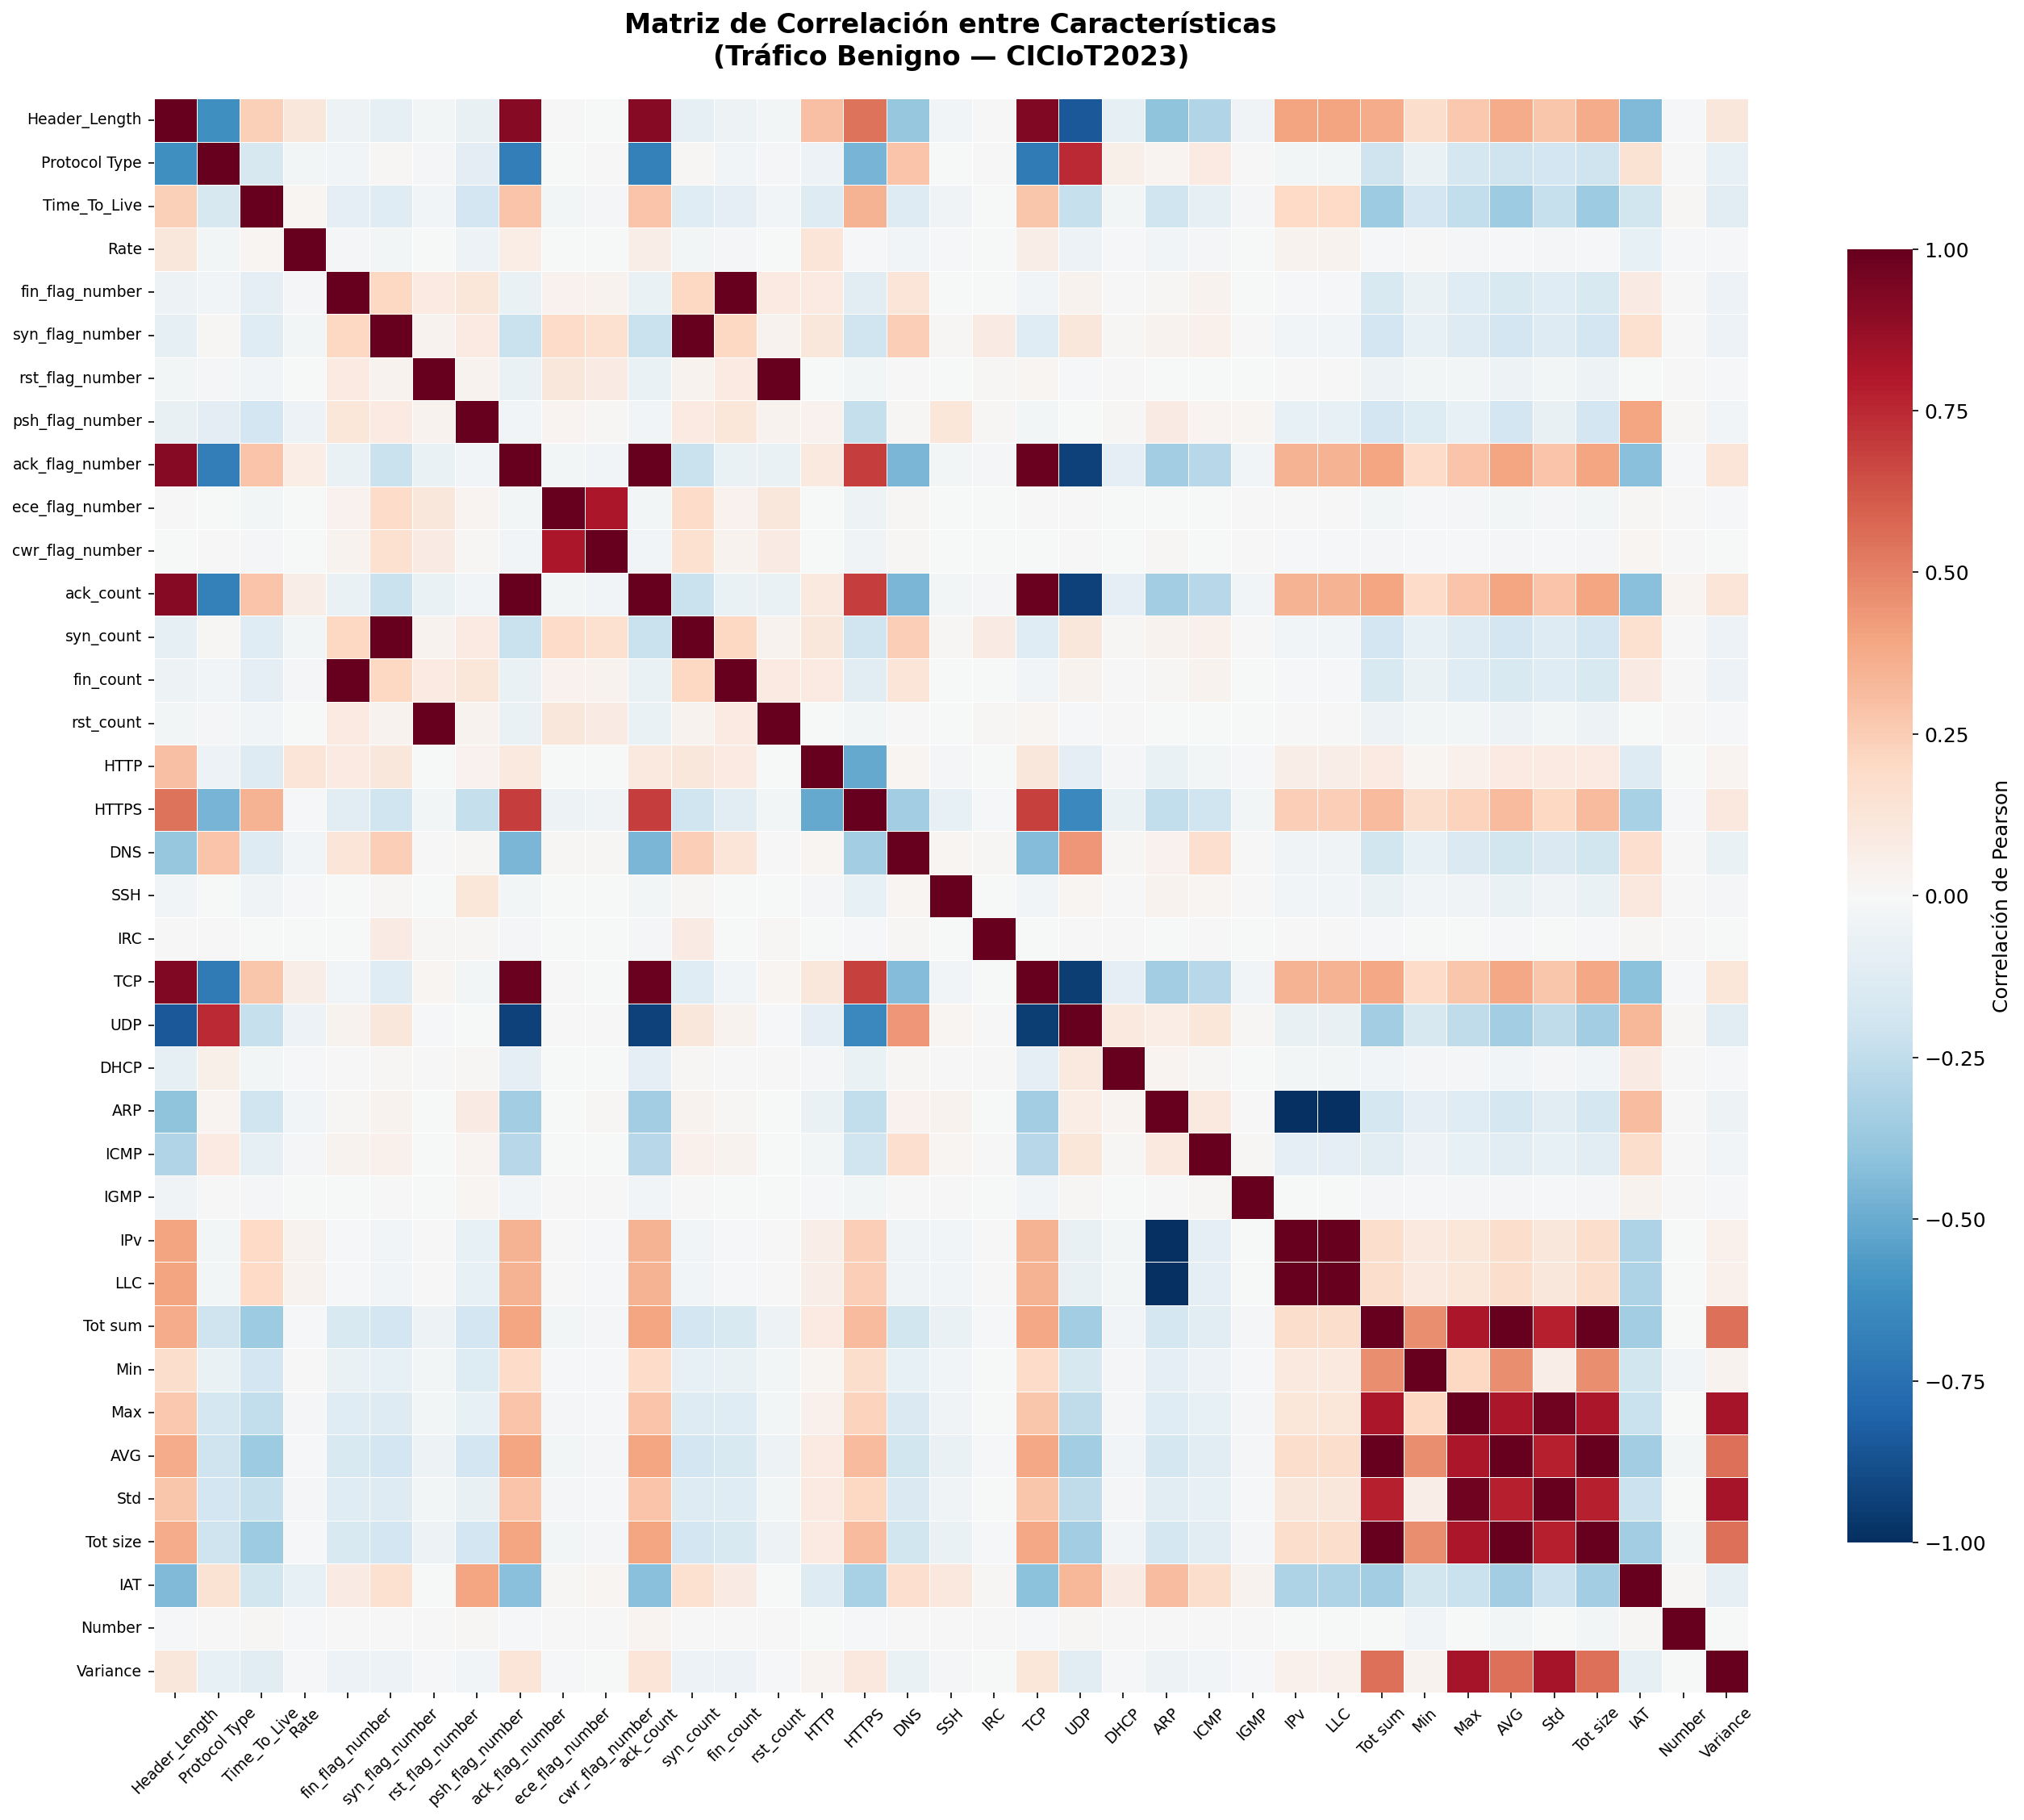

  ✓ eda_heatmap_correlacion.png


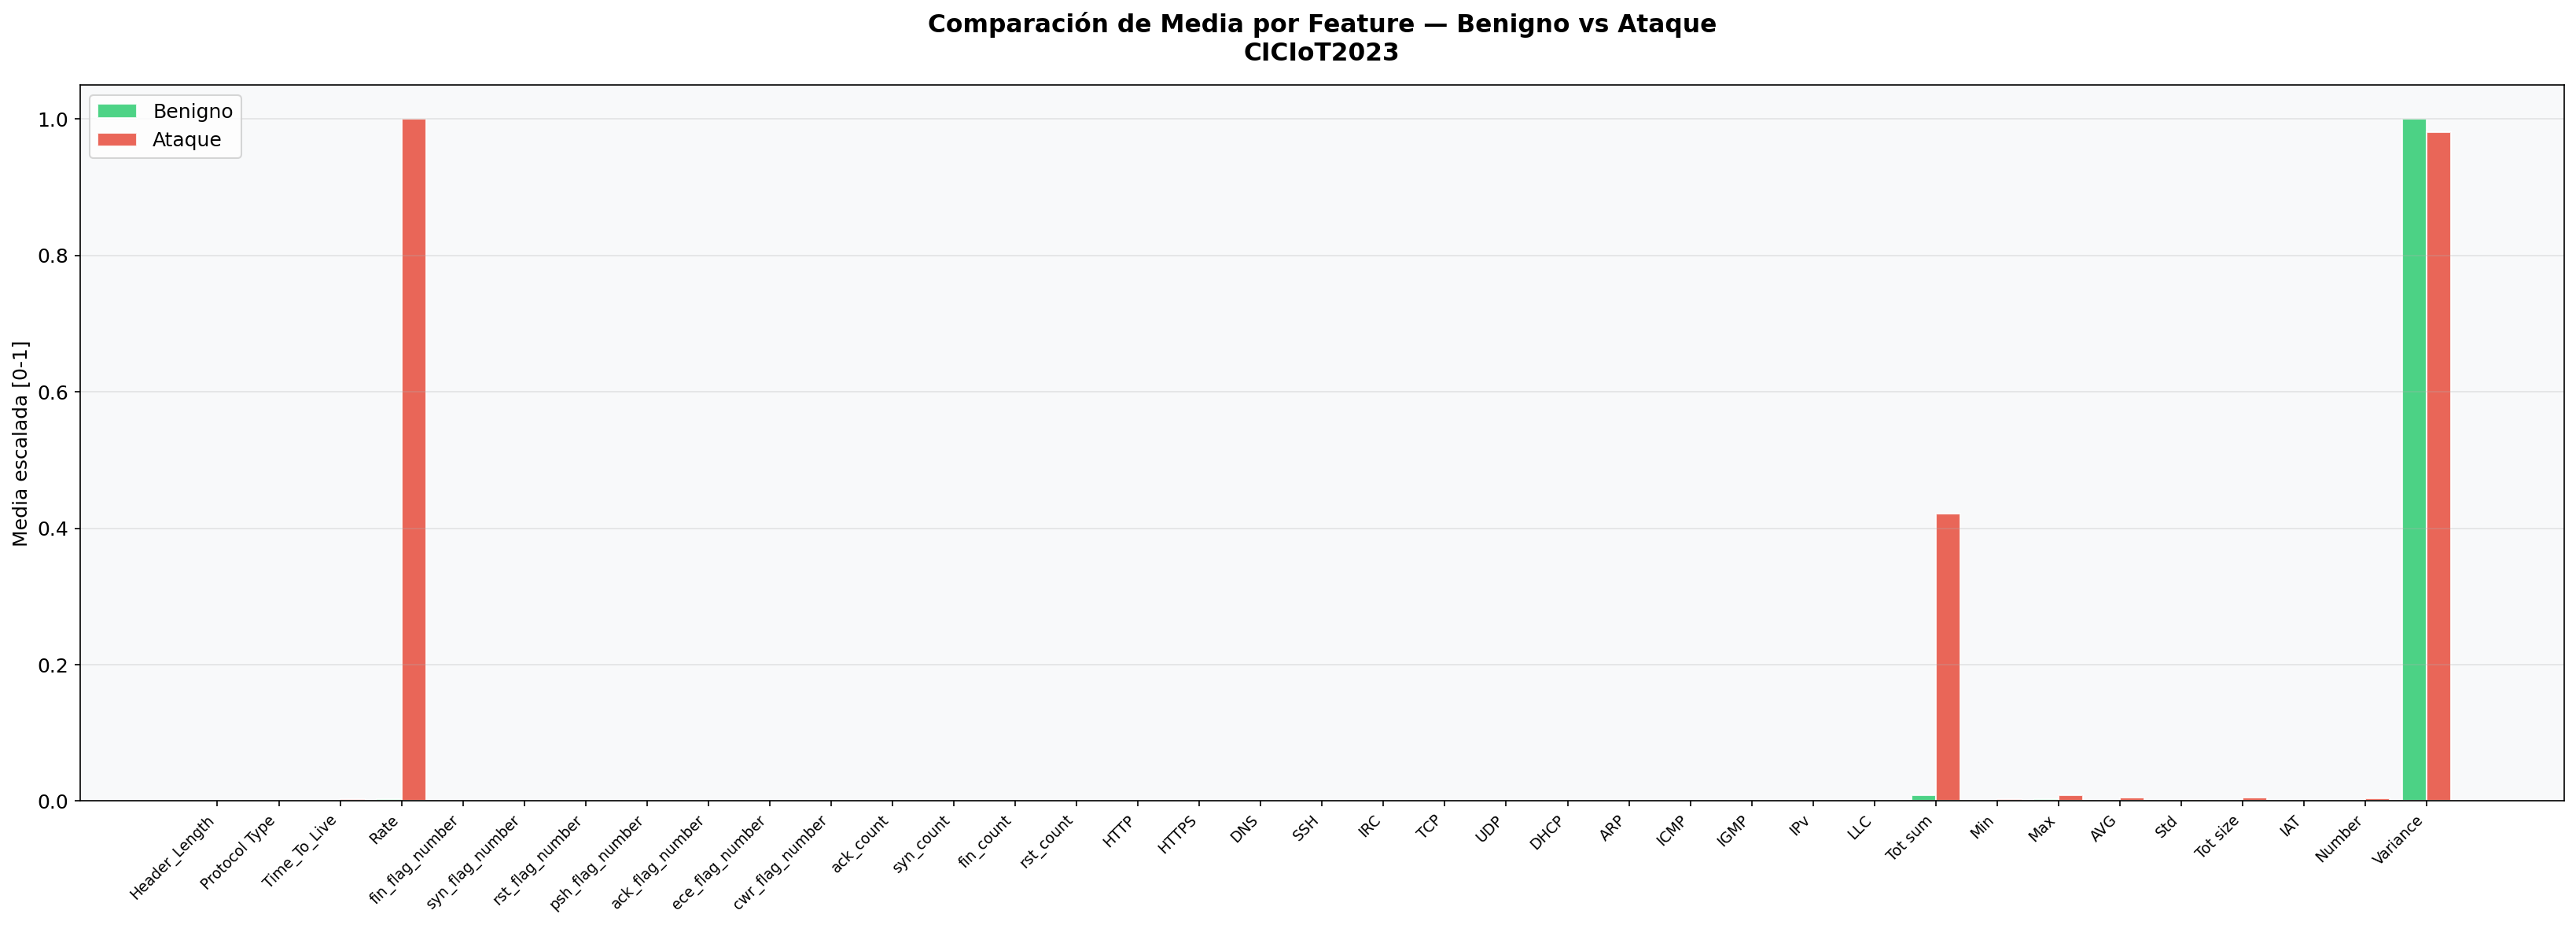

  ✓ eda_comparacion_features.png

  Todas las gráficas EDA guardadas en: C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\fase3_salidas\graficas_pipeline


In [13]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 7 — EDA (ANÁLISIS EXPLORATORIO)
#  Genera gráficas sobre datos originales y normalizados
# ════════════════════════════════════════════════════════════════

import seaborn as sns

# Cargar muestras para gráficas
print('  Cargando muestras para EDA...')
df_ben_full = pd.read_csv(PATH_BENIGN_FULL, usecols=FEATURES_37)
df_atk_full = pd.read_csv(PATH_ATK, usecols=lambda c: c in FEATURES_37)

df_ben = df_ben_full.sample(n=min(SAMPLE_EDA, len(df_ben_full)), random_state=SEED)
df_atk = df_atk_full.sample(n=min(SAMPLE_EDA, len(df_atk_full)), random_state=SEED)
del df_ben_full, df_atk_full; gc.collect()
print(f'  Benigno: {len(df_ben):,} muestras  |  Ataque: {len(df_atk):,} muestras')

# ── Gráfica 1: Histogramas benigno vs ataque ──────────────────────
FEATS_HIST = ['Rate', 'Header_Length', 'Time_To_Live', 'IAT',
              'Number', 'syn_count', 'ack_flag_number', 'tot sum' if 'tot sum' in FEATURES_37 else 'Tot sum',
              'TCP', 'UDP', 'HTTPS', 'ICMP']
FEATS_HIST = [f for f in FEATS_HIST if f in FEATURES_37][:12]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Distribución de Features Clave — Benigno vs Ataque\nCICIoT2023 (escala original)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), FEATS_HIST):
    if feat not in df_ben.columns:
        continue
    lim = max(np.percentile(df_ben[feat].dropna(), 99),
              np.percentile(df_atk[feat].dropna(), 99))
    ax.hist(df_ben[feat].clip(upper=lim), bins=50, color=PALETA['benigno'],
            alpha=0.65, label='Benigno', density=True)
    ax.hist(df_atk[feat].clip(upper=lim), bins=50, color=PALETA['ataque'],
            alpha=0.65, label='Ataque',  density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(GRAF_DIR / 'eda_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ eda_histogramas.png')

# ── Gráfica 2: Boxplots ───────────────────────────────────────────
FEATS_BOX = ['Header_Length', 'Time_To_Live', 'Rate',
             'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
             'psh_flag_number', 'ack_flag_number']
FEATS_BOX = [f for f in FEATS_BOX if f in FEATURES_37]

df_ben_box = df_ben[FEATS_BOX].copy(); df_ben_box['tipo'] = 'Benigno'
df_atk_box = df_atk[FEATS_BOX].copy(); df_atk_box['tipo'] = 'Ataque'
df_box = pd.concat([df_ben_box, df_atk_box], ignore_index=True)

n_cols = 4
n_rows = (len(FEATS_BOX) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Boxplots — Detección de Outliers (escala log)\nCICIoT2023',
             fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), FEATS_BOX):
    p99 = df_box[feat].quantile(0.99)
    df_tmp = df_box[[feat, 'tipo']].copy()
    df_tmp[feat] = df_tmp[feat].clip(upper=p99)
    sns.boxplot(data=df_tmp, x='tipo', y=feat,
                palette={'Benigno': PALETA['benigno'], 'Ataque': PALETA['ataque']},
                ax=ax, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

for ax in axes.flatten()[len(FEATS_BOX):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(GRAF_DIR / 'eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ eda_boxplots.png')
del df_ben_box, df_atk_box, df_box, df_tmp; gc.collect()

# ── Gráfica 3: Heatmap de correlación (datos normalizados) ────────
print('  Generando heatmap de correlación...')
val_norm = np.load(NORM_DIR / 'val_norm.npy')
df_corr  = pd.DataFrame(val_norm, columns=FEATURES_37).sample(
    n=min(SAMPLE_EDA, len(val_norm)), random_state=SEED)
del val_norm; gc.collect()
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, linecolor='white',
            square=True, cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'})
ax.set_title('Matriz de Correlación entre Características\n'
             '(Tráfico Benigno — CICIoT2023)',
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'eda_heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ eda_heatmap_correlacion.png')
del df_corr, corr; gc.collect()

# ── Gráfica 4: Comparación de medias benigno vs ataque ────────────
from sklearn.preprocessing import MinMaxScaler as MMS

medias_ben = df_ben[FEATURES_37].mean()
medias_atk = df_atk[FEATURES_37].mean()
vals_scaled = MMS().fit_transform(np.vstack([medias_ben.values, medias_atk.values]).T).T

x, w = np.arange(len(FEATURES_37)), 0.4
fig, ax = plt.subplots(figsize=(22, 8))
ax.set_facecolor(PALETA['fondo'])
ax.bar(x - w/2, vals_scaled[0], w, color=PALETA['benigno'],
       alpha=0.85, label='Benigno', edgecolor='white')
ax.bar(x + w/2, vals_scaled[1], w, color=PALETA['ataque'],
       alpha=0.85, label='Ataque',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(FEATURES_37, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Media escalada [0-1]')
ax.set_title('Comparación de Media por Feature — Benigno vs Ataque\nCICIoT2023',
             fontweight='bold', pad=15)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'eda_comparacion_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ eda_comparacion_features.png')
del df_ben, df_atk; gc.collect()

print()
print(f'  Todas las gráficas EDA guardadas en: {GRAF_DIR}')

---
## SECCIÓN 8 — Ventanas Deslizantes T=20, step=20
Convierte arrays `(N, 37)` → tensores `(samples, 20, 37)` para el LSTM-AE.

In [14]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 8 — VENTANAS DESLIZANTES
#  T=20 timesteps, step=20 (sin overlap)
#  Cada ventana = 20 registros de flujo consecutivos
#  step=T garantiza que cada fila aparece en exactamente 1 ventana
# ════════════════════════════════════════════════════════════════

def crear_ventanas(arr, T, step):
    """
    Convierte array (N, F) en tensor (samples, T, F).
    
    Args:
        arr:  array normalizado (N, F)
        T:    timesteps por ventana
        step: paso entre ventanas (step=T → sin overlap)
    
    Returns:
        tensor (n_ventanas, T, F)
    
    Nota: n_ventanas = (N - T) // step + 1
          Las filas sobrantes que no completan una ventana se descartan.
    """
    N, F = arr.shape
    n_ventanas = (N - T) // step + 1
    out = np.empty((n_ventanas, T, F), dtype=arr.dtype)  # pre-alocar
    for i in range(n_ventanas):
        inicio = i * step
        out[i] = arr[inicio : inicio + T]
    return out

print('=' * 65)
print(f'  VENTANAS DESLIZANTES — T={T}, step={STEP} (sin overlap)')
print('=' * 65)
print(f'  Entrada: arrays (N, {len(FEATURES_37)})')
print(f'  Salida:  tensores (samples, {T}, {len(FEATURES_37)})')
print()

# ── Train ──────────────────────────────────────────────────────────
print('  PASO 1 — Train')
train_norm = np.load(NORM_DIR / 'train_norm.npy')
train_win  = crear_ventanas(train_norm, T, STEP)
np.save(WIN_DIR / f'train_w{T}.npy', train_win)
filas_desc = train_norm.shape[0] - train_win.shape[0] * T
size_mb    = (WIN_DIR / f'train_w{T}.npy').stat().st_size / (1024**2)
print(f'  train_w{T}.npy  {train_norm.shape} → {train_win.shape}  '
      f'({filas_desc} filas descartadas)  {size_mb:.1f} MB')
del train_norm, train_win; gc.collect()

# ── Val ────────────────────────────────────────────────────────────
print('  PASO 2 — Val benigno')
val_norm = np.load(NORM_DIR / 'val_norm.npy')
val_win  = crear_ventanas(val_norm, T, STEP)
np.save(WIN_DIR / f'val_w{T}.npy', val_win)
filas_desc = val_norm.shape[0] - val_win.shape[0] * T
size_mb    = (WIN_DIR / f'val_w{T}.npy').stat().st_size / (1024**2)
print(f'  val_w{T}.npy    {val_norm.shape} → {val_win.shape}  '
      f'({filas_desc} filas descartadas)  {size_mb:.1f} MB')
del val_norm, val_win; gc.collect()

# ── Ataques + etiquetas alineadas ──────────────────────────────────
print('  PASO 3 — Ataques')
atk_norm   = np.load(NORM_DIR / 'atk_norm.npy')
atk_labels = np.load(NORM_DIR / 'atk_labels.npy', allow_pickle=True)
atk_win    = crear_ventanas(atk_norm, T, STEP)
np.save(WIN_DIR / f'atk_w{T}.npy', atk_win)
filas_desc = atk_norm.shape[0] - atk_win.shape[0] * T
size_mb    = (WIN_DIR / f'atk_w{T}.npy').stat().st_size / (1024**2)
print(f'  atk_w{T}.npy    {atk_norm.shape} → {atk_win.shape}  '
      f'({filas_desc} filas descartadas)  {size_mb:.1f} MB')

# Etiqueta de cada ventana = etiqueta del primer registro de esa ventana
# Válido porque el muestreo estratificado garantiza ventanas no mixtas
n_ventanas = atk_win.shape[0]
labels_win = np.array([atk_labels[i * STEP] for i in range(n_ventanas)])
np.save(WIN_DIR / f'atk_labels_w{T}.npy', labels_win)
print(f'  atk_labels_w{T}.npy  {labels_win.shape}')
del atk_norm, atk_win, atk_labels; gc.collect()

# ── Distribución de clases en ventanas ─────────────────────────────
print()
print('  Distribución de clases en ventanas de ataque:')
clases, conteos_v = np.unique(labels_win, return_counts=True)
for c, n in zip(clases, conteos_v):
    print(f'    {c:<45}  {n:>6,} ventanas')
del labels_win

# ── Resumen ────────────────────────────────────────────────────────
print()
print('=' * 65)
print(f'  RESUMEN FINAL — ventanas/ (T={T}, step={STEP})')
print('=' * 65)
for p in sorted(WIN_DIR.glob('*.npy')):
    arr  = np.load(p, mmap_mode='r') if 'labels' not in p.name else \
           np.load(p, allow_pickle=True)
    size = p.stat().st_size / (1024**2)
    print(f'  {p.name:30}  {str(arr.shape):30}  {size:.1f} MB')

  VENTANAS DESLIZANTES — T=20, step=20 (sin overlap)
  Entrada: arrays (N, 37)
  Salida:  tensores (samples, 20, 37)

  PASO 1 — Train
  train_w20.npy  (875100, 37) → (43755, 20, 37)  (0 filas descartadas)  123.5 MB
  PASO 2 — Val benigno
  val_w20.npy    (218776, 37) → (10938, 20, 37)  (16 filas descartadas)  30.9 MB
  PASO 3 — Ataques
  atk_w20.npy    (218760, 37) → (10938, 20, 37)  (0 filas descartadas)  30.9 MB
  atk_labels_w20.npy  (10938,)

  Distribución de clases en ventanas de ataque:
    Backdoor_Malware                                   26 ventanas
    BrowserHijacking                                   24 ventanas
    CommandInjection                                   23 ventanas
    DDoS-ACK_Fragmentation                             92 ventanas
    DDoS-HTTP_Flood                                    36 ventanas
    DDoS-ICMP_Flood                                 1,634 ventanas
    DDoS-ICMP_Fragmentation                           110 ventanas
    DDoS-PSHACK_FLOOD           

---
## SECCIÓN 9 — Verificación de Integridad Final
Confirma que todos los artefactos son consistentes antes de pasar a la Fase 4.

In [15]:
# ════════════════════════════════════════════════════════════════
#  SECCIÓN 9 — VERIFICACIÓN DE INTEGRIDAD FINAL
#  Confirma shapes, tipos, ausencia de NaN/inf y proporciones
# ════════════════════════════════════════════════════════════════

import pickle

errores = []

def check(condicion, mensaje_ok, mensaje_err):
    if condicion:
        print(f'  ✓ {mensaje_ok}')
    else:
        print(f'  ✗ {mensaje_err}')
        errores.append(mensaje_err)

print('=' * 65)
print('  VERIFICACIÓN — Archivos normalizados')
print('=' * 65)

# Scaler
with open(NORM_DIR / 'scaler.pkl', 'rb') as f:
    sc = pickle.load(f)
check(sc.center_.shape[0] == 37, f'scaler: 37 features ✓', 'scaler: features incorrectas')
check(sc.scale_.min() > 0, 'scaler: todos los IQR > 0 (no hay división por cero)', 'scaler: IQR=0 detectado')

# Arrays normalizados
for nombre_npy in ['train_norm.npy', 'val_norm.npy', 'atk_norm.npy']:
    arr = np.load(NORM_DIR / nombre_npy)
    check(arr.shape[1] == 37,        f'{nombre_npy}: 37 features ✓',       f'{nombre_npy}: features != 37')
    check(np.isnan(arr).sum() == 0,  f'{nombre_npy}: sin NaN ✓',           f'{nombre_npy}: tiene NaN')
    check(np.isinf(arr).sum() == 0,  f'{nombre_npy}: sin inf ✓',           f'{nombre_npy}: tiene inf')
    check(arr.dtype == np.float32,   f'{nombre_npy}: dtype float32 ✓',     f'{nombre_npy}: dtype incorrecto')
    del arr

# Labels de ataque
atk_shape  = np.load(NORM_DIR / 'atk_norm.npy', mmap_mode='r').shape
atk_labels = np.load(NORM_DIR / 'atk_labels.npy', allow_pickle=True)
check(len(atk_labels) == atk_shape[0],
      f'atk_labels: {len(atk_labels):,} == atk_norm filas {atk_shape[0]:,} ✓',
      f'atk_labels: no coincide con atk_norm')
check(len(np.unique(atk_labels)) == 33,
      f'atk_labels: 33 clases de ataque ✓',
      f'atk_labels: clases incorrectas ({len(np.unique(atk_labels))})')

# Proporción train/val
train_shape = np.load(NORM_DIR / 'train_norm.npy', mmap_mode='r').shape
val_shape   = np.load(NORM_DIR / 'val_norm.npy',   mmap_mode='r').shape
total_ben   = train_shape[0] + val_shape[0]
prop_val    = val_shape[0] / total_ben
check(abs(prop_val - 0.20) < 0.01,
      f'proporción val: {prop_val*100:.1f}% ≈ 20% ✓',
      f'proporción val: {prop_val*100:.1f}% ≠ 20%')

print()
print('=' * 65)
print('  VERIFICACIÓN — Ventanas deslizantes')
print('=' * 65)

n_train_w = n_val_w = n_atk_w = 0
for nombre_npy in [f'train_w{T}.npy', f'val_w{T}.npy', f'atk_w{T}.npy']:
    arr = np.load(WIN_DIR / nombre_npy)
    check(arr.shape[1] == T,          f'{nombre_npy}: T={T} ✓',           f'{nombre_npy}: T incorrecto')
    check(arr.shape[2] == 37,         f'{nombre_npy}: 37 features ✓',     f'{nombre_npy}: features incorrectas')
    check(np.isnan(arr).sum() == 0,   f'{nombre_npy}: sin NaN ✓',         f'{nombre_npy}: tiene NaN')
    check(np.isinf(arr).sum() == 0,   f'{nombre_npy}: sin inf ✓',         f'{nombre_npy}: tiene inf')
    if 'train' in nombre_npy: n_train_w = arr.shape[0]
    if 'val'   in nombre_npy: n_val_w   = arr.shape[0]
    if 'atk'   in nombre_npy: n_atk_w   = arr.shape[0]
    del arr

# Labels de ventanas de ataque
lab_w = np.load(WIN_DIR / f'atk_labels_w{T}.npy', allow_pickle=True)
check(len(lab_w) == n_atk_w,
      f'atk_labels_w{T}: {len(lab_w):,} == atk_w filas {n_atk_w:,} ✓',
      f'atk_labels_w{T}: no coincide con atk_w')
check(len(np.unique(lab_w)) == 33,
      f'atk_labels_w{T}: 33 clases ✓',
      f'atk_labels_w{T}: clases incorrectas')

# ── Tabla resumen final ────────────────────────────────────────────
print()
print('=' * 65)
print('  TABLA RESUMEN FINAL — Fase 3 completa')
print('=' * 65)
print(f'  {"Artefacto":<35} {"Shape":>25} {"Uso"}')
print(f'  {"-"*75}')

resumen = [
    ('train_norm.npy', train_shape, 'Fit+entrenamiento LSTM-AE'),
    ('val_norm.npy',   val_shape,   'Calibración umbral θ'),
    ('atk_norm.npy',   atk_shape,   'Evaluación (F1, Recall)'),
    (f'train_w{T}.npy', (n_train_w, T, 37), 'Entrada LSTM-AE (train)'),
    (f'val_w{T}.npy',   (n_val_w,   T, 37), 'Entrada LSTM-AE (val)'),
    (f'atk_w{T}.npy',  (n_atk_w,   T, 37), 'Entrada LSTM-AE (eval)'),
]
for nombre, shape, uso in resumen:
    print(f'  {nombre:<35} {str(shape):>25}  {uso}')

print()
if not errores:
    print('  ✅ FASE 3 COMPLETA — Todo verificado. Listo para Fase 4 (Modelado)')
else:
    print(f'  ⚠ {len(errores)} inconsistencia(s) detectada(s):')
    for e in errores:
        print(f'    - {e}')

print()
print('  Para cargar en el notebook del modelo (Fase 4):')
print(f'  WIN_DIR  = Path(r"{WIN_DIR}")')
print(f'  T        = {T}')
print(f'  train_w  = np.load(WIN_DIR / "train_w{T}.npy")')
print(f'  val_w    = np.load(WIN_DIR / "val_w{T}.npy")')
print(f'  atk_w    = np.load(WIN_DIR / "atk_w{T}.npy")')
print(f'  atk_lab  = np.load(WIN_DIR / "atk_labels_w{T}.npy", allow_pickle=True)')

  VERIFICACIÓN — Archivos normalizados
  ✓ scaler: 37 features ✓
  ✓ scaler: todos los IQR > 0 (no hay división por cero)
  ✓ train_norm.npy: 37 features ✓
  ✓ train_norm.npy: sin NaN ✓
  ✓ train_norm.npy: sin inf ✓
  ✓ train_norm.npy: dtype float32 ✓
  ✓ val_norm.npy: 37 features ✓
  ✓ val_norm.npy: sin NaN ✓
  ✓ val_norm.npy: sin inf ✓
  ✓ val_norm.npy: dtype float32 ✓
  ✓ atk_norm.npy: 37 features ✓
  ✓ atk_norm.npy: sin NaN ✓
  ✓ atk_norm.npy: sin inf ✓
  ✓ atk_norm.npy: dtype float32 ✓
  ✓ atk_labels: 218,760 == atk_norm filas 218,760 ✓
  ✓ atk_labels: 33 clases de ataque ✓
  ✓ proporción val: 20.0% ≈ 20% ✓

  VERIFICACIÓN — Ventanas deslizantes
  ✓ train_w20.npy: T=20 ✓
  ✓ train_w20.npy: 37 features ✓
  ✓ train_w20.npy: sin NaN ✓
  ✓ train_w20.npy: sin inf ✓
  ✓ val_w20.npy: T=20 ✓
  ✓ val_w20.npy: 37 features ✓
  ✓ val_w20.npy: sin NaN ✓
  ✓ val_w20.npy: sin inf ✓
  ✓ atk_w20.npy: T=20 ✓
  ✓ atk_w20.npy: 37 features ✓
  ✓ atk_w20.npy: sin NaN ✓
  ✓ atk_w20.npy: sin inf ✓
  ✓ at

In [17]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
PART_DIR = BASE / "particiones"      # ← rutas originales donde están los archivos
NORM_DIR = BASE / "normalizacion"

FEATURES_MOSTRAR = [
    'Rate', 'Header_Length', 'syn_count', 'ack_flag_number',
    'Number', 'IAT', 'fin_count', 'rst_count',
    'ARP', 'Min'                     # ← Min en vez de Tot sum
]

FEATURES_37 = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

df_orig = pd.read_csv(
    PART_DIR / "benign_train_80.csv",
    usecols=FEATURES_MOSTRAR, nrows=10
)[FEATURES_MOSTRAR]

with open(NORM_DIR / "scaler.pkl", 'rb') as f:
    scaler = pickle.load(f)

df_full = pd.read_csv(
    PART_DIR / "benign_train_80.csv",
    usecols=FEATURES_37, nrows=10
)[FEATURES_37]

df_scaled_full = pd.DataFrame(
    scaler.transform(df_full).round(4), columns=FEATURES_37)
df_scaled = df_scaled_full[FEATURES_MOSTRAR]

idx = [FEATURES_37.index(f) for f in FEATURES_MOSTRAR]
df_params = pd.DataFrame({
    'Feature':       FEATURES_MOSTRAR,
    'Q2 (mediana)':  scaler.center_[idx].round(4),
    'IQR (Q3-Q1)':   scaler.scale_[idx].round(4),
})

print("=" * 70)
print("  VALORES ORIGINALES — primeras 10 filas (features clave)")
print("=" * 70)
print(df_orig.to_string(index=True))

print()
print("=" * 70)
print("  VALORES NORMALIZADOS — X' = (X - Q2) / IQR")
print("=" * 70)
print(df_scaled.to_string(index=True))

print()
print("=" * 70)
print("  PARÁMETROS APRENDIDOS POR EL ROBUSTSCALER")
print("=" * 70)
print(df_params.to_string(index=False))


  VALORES ORIGINALES — primeras 10 filas (features clave)
          Rate  Header_Length  syn_count  ack_flag_number  Number       IAT  fin_count  rst_count  ARP  Min
0   596.162888           32.0          0              1.0      10  0.003534          0          0  0.0   66
1   403.193786           32.0          0              1.0      10  0.002562          0          0  0.0   66
2    55.735815           20.8          0              0.7      10  0.017986          0          0  0.1   60
3   125.856053           26.0          0              0.8      10  0.008821          1          0  0.0   66
4  7616.313782           32.0          0              1.0      10  0.000269          0          0  0.0   66
5   515.144191           25.6          1              0.7      10  0.003621          0          0  0.0   60
6   149.525823           23.2          1              0.6      10  0.006992          1          0  0.0   60
7   184.925070           32.0          0              1.0      10  0.005457   